In [1]:
import psycopg2
import pandas as pd

conn = psycopg2.connect(
    host='127.0.0.1', port=5455, dbname='postgres',
    user='postgres', password='postgres'
)
cur = conn.cursor()

# ── All tables in int and raw ─────────────────────────────────────
cur.execute("""
    SELECT table_schema, table_name
    FROM information_schema.tables
    WHERE table_schema IN ('int', 'raw')
    ORDER BY table_schema, table_name
""")
rows = cur.fetchall()
print("=== TABLES ===")
for r in rows:
    print(f"  {r[0]}.{r[1]}")

# ── All columns in int schema ─────────────────────────────────────
cur.execute("""
    SELECT
        table_name,
        column_name,
        data_type,
        is_nullable
    FROM information_schema.columns
    WHERE table_schema = 'int'
    ORDER BY table_name, ordinal_position
""")
rows = cur.fetchall()
cols = ['table', 'column', 'type', 'nullable']
df = pd.DataFrame(rows, columns=cols)

print("\n=== INT SCHEMA — FULL COLUMN INVENTORY ===")
for table in df['table'].unique():
    t = df[df['table'] == table]
    print(f"\n--- {table} ({len(t)} columns) ---")
    for _, r in t.iterrows():
        print(f"  {r['column']:<45} {r['type']:<25} nullable={r['nullable']}")

# ── Row counts per int table ──────────────────────────────────────
print("\n=== INT TABLE ROW COUNTS ===")
for table in df['table'].unique():
    cur.execute(f"SELECT COUNT(*) FROM int.{table}")
    n = cur.fetchone()[0]
    print(f"  {table}: {n:,}")

# ── Raw schema columns (for reference) ───────────────────────────
cur.execute("""
    SELECT table_name, column_name, data_type
    FROM information_schema.columns
    WHERE table_schema = 'raw'
    ORDER BY table_name, ordinal_position
""")
rows = cur.fetchall()
raw_df = pd.DataFrame(rows, columns=['table','column','type'])
print("\n=== RAW SCHEMA — FULL COLUMN INVENTORY ===")
for table in raw_df['table'].unique():
    t = raw_df[raw_df['table'] == table]
    print(f"\n--- {table} ({len(t)} columns) ---")
    for _, r in t.iterrows():
        print(f"  {r['column']:<45} {r['type']}")

=== TABLES ===
  int.int_game_environment
  int.int_game_model_features
  int.int_game_team_features
  int.int_team_season_context
  int.int_team_season_features
  int.venue_elevations
  raw.advanced_stats
  raw.game_weather
  raw.games
  raw.odds
  raw.plays
  raw.recruiting
  raw.sp_ratings
  raw.team_stats
  raw.teams
  raw.venues

=== INT SCHEMA — FULL COLUMN INVENTORY ===

--- int_game_environment (22 columns) ---
  game_id                                       bigint                    nullable=YES
  season                                        integer                   nullable=YES
  week                                          integer                   nullable=YES
  home_team                                     text                      nullable=YES
  away_team                                     text                      nullable=YES
  venue_id                                      bigint                    nullable=YES
  is_dome                                       boolean

In [2]:
import psycopg2
import pandas as pd
import numpy as np

conn = psycopg2.connect(
    host='127.0.0.1', port=5455, dbname='postgres',
    user='postgres', password='postgres'
)
cur = conn.cursor()

# ── 0. What columns does this table actually have? ────────────────
cur.execute("""
    SELECT column_name, data_type
    FROM information_schema.columns
    WHERE table_schema = 'int' AND table_name = 'int_game_model_features'
    ORDER BY ordinal_position
""")
cols_meta = cur.fetchall()
print("=== int_game_model_features — actual columns ===")
for col, dtype in cols_meta:
    print(f"  {col:<45} {dtype}")

col_names = [r[0] for r in cols_meta]

# ── 1. Row count and season coverage ─────────────────────────────
cur.execute("""
    SELECT season, COUNT(*) AS n
    FROM int.int_game_model_features
    GROUP BY season
    ORDER BY season
""")
print("\n=== Row count by season ===")
for row in cur.fetchall():
    print(f"  {row[0]}: {row[1]}")

# ── 2. Null counts per column ─────────────────────────────────────
null_query = "SELECT " + ", ".join([
    f"SUM(CASE WHEN {c} IS NULL THEN 1 ELSE 0 END) AS {c}"
    for c in col_names
]) + " FROM int.int_game_model_features"
cur.execute(null_query)
null_counts = dict(zip(col_names, cur.fetchone()))
print("\n=== Null counts per column ===")
for col, n in null_counts.items():
    flag = " !" if n and n > 0 else ""
    print(f"  {col:<45} {n}{flag}")

# ── 3. Sample rows ────────────────────────────────────────────────
cur.execute("SELECT * FROM int.int_game_model_features ORDER BY season, game_id LIMIT 5")
rows = cur.fetchall()
sample = pd.DataFrame(rows, columns=col_names)
print("\n=== Sample rows (5) ===")
print(sample.to_string(index=False))

# ── 4. wind_chill — verify against NWS formula ───────────────────
# Join on game_id only (int_game_environment has home_team/away_team, not team_name)
cur.execute("""
    SELECT
        f.wind_chill,
        e.temperature_f,
        e.wind_speed_mph
    FROM int.int_game_model_features f
    JOIN int.int_game_environment e ON e.game_id = f.game_id
    WHERE f.wind_chill IS NOT NULL
      AND e.temperature_f IS NOT NULL
      AND e.wind_speed_mph IS NOT NULL
    LIMIT 300
""")
wc_rows = cur.fetchall()
wc_df = pd.DataFrame(wc_rows, columns=['wind_chill','temperature_f','wind_speed_mph']).astype(float)

wc_df['wc_nws'] = np.where(
    (wc_df['temperature_f'] <= 50) & (wc_df['wind_speed_mph'] >= 3),
    35.74 + 0.6215 * wc_df['temperature_f']
    - 35.75 * wc_df['wind_speed_mph']**0.16
    + 0.4275 * wc_df['temperature_f'] * wc_df['wind_speed_mph']**0.16,
    wc_df['temperature_f']
)
wc_df['delta'] = wc_df['wind_chill'] - wc_df['wc_nws']

print("\n=== wind_chill audit ===")
print(f"Rows checked: {len(wc_df)}")
print(f"Delta (stored - NWS): mean={wc_df['delta'].mean():.4f}, std={wc_df['delta'].std():.4f}, max_abs={wc_df['delta'].abs().max():.4f}")
cold = wc_df[(wc_df['temperature_f'] <= 50) & (wc_df['wind_speed_mph'] >= 3)].head(10)
print(f"Cold-weather rows (formula applies): {len(wc_df[(wc_df['temperature_f'] <= 50) & (wc_df['wind_speed_mph'] >= 3)])}")
print(cold[['temperature_f','wind_speed_mph','wind_chill','wc_nws','delta']].to_string(index=False))

# ── 5. elo_sp_divergence — reverse-engineer ───────────────────────
cur.execute("""
    SELECT
        f.game_id,
        f.team_name,
        f.elo_sp_divergence,
        f.pregame_elo,
        f.opponent_pregame_elo,
        f.sp_rating
    FROM int.int_game_model_features f
    WHERE f.elo_sp_divergence IS NOT NULL
      AND f.pregame_elo IS NOT NULL
    LIMIT 100
""")
div_rows = cur.fetchall()
div_df = pd.DataFrame(div_rows, columns=['game_id','team_name','elo_sp_divergence',
                                          'pregame_elo','opp_pregame_elo','sp_rating']).astype(float, errors='ignore')
for c in ['elo_sp_divergence','pregame_elo','opp_pregame_elo','sp_rating']:
    div_df[c] = div_df[c].astype(float)

div_df['elo_diff'] = div_df['pregame_elo'] - div_df['opp_pregame_elo']
div_df['hyp_abs_elo_diff'] = div_df['elo_diff'].abs()
div_df['delta_abs'] = div_df['elo_sp_divergence'] - div_df['hyp_abs_elo_diff']

print("\n=== elo_sp_divergence audit ===")
print(f"Stored: mean={div_df['elo_sp_divergence'].mean():.2f}, std={div_df['elo_sp_divergence'].std():.2f}, min={div_df['elo_sp_divergence'].min():.2f}, max={div_df['elo_sp_divergence'].max():.2f}")
print(f"\nHypothesis |pregame_elo - opp_pregame_elo|: delta mean={div_df['delta_abs'].mean():.4f}, std={div_df['delta_abs'].std():.4f}, max_abs={div_df['delta_abs'].abs().max():.4f}")
print("\nSample:")
print(div_df[['team_name','pregame_elo','opp_pregame_elo','sp_rating',
              'elo_sp_divergence','hyp_abs_elo_diff','delta_abs']].head(12).to_string(index=False))

# ── 6. Archetype index distribution ──────────────────────────────
cur.execute("""
    SELECT off_archetype_idx, def_archetype_idx, COUNT(*) as n
    FROM int.int_game_model_features
    GROUP BY off_archetype_idx, def_archetype_idx
    ORDER BY off_archetype_idx, def_archetype_idx
""")
arch_df = pd.DataFrame(cur.fetchall(), columns=['off_idx','def_idx','n'])
print("\n=== Archetype index distribution ===")
print(arch_df.to_string(index=False))
print(f"Distinct off values: {sorted(arch_df['off_idx'].unique())}")
print(f"Distinct def values: {sorted(arch_df['def_idx'].unique())}")

# ── 7. Style delta distributions ─────────────────────────────────
cur.execute("""
    SELECT rush_rate_std_downs_delta, rush_rate_pass_downs_delta, close_game_play_count_delta
    FROM int.int_game_model_features
""")
delta_df = pd.DataFrame(cur.fetchall(),
    columns=['rush_rate_std_downs_delta','rush_rate_pass_downs_delta','close_game_play_count_delta']).astype(float)
print("\n=== Style delta distributions ===")
for col in delta_df.columns:
    s = delta_df[col].dropna()
    print(f"  {col}: mean={s.mean():.4f}, std={s.std():.4f}, min={s.min():.4f}, max={s.max():.4f}, pct_zero={( s==0).mean()*100:.1f}%")

# ── 8. Coverage vs rebuild pool ───────────────────────────────────
cur.execute("""
    SELECT COUNT(DISTINCT f.game_id)
    FROM int.int_game_model_features f
    JOIN raw.games g ON g.id = f.game_id
    JOIN int.int_team_season_features ht ON ht.team_name = g.home_team AND ht.season = g.season
    JOIN int.int_team_season_features at ON at.team_name = g.away_team AND at.season = g.season
    WHERE g.conference_game = TRUE
      AND g.season IN (2022, 2023, 2024, 2025)
      AND g.week BETWEEN 5 AND 14
      AND ht.conference != 'FBS Independents'
      AND at.conference != 'FBS Independents'
      AND ht.conference != 'Pac-12'
      AND NOT (ht.conference = 'American Athletic' AND g.season = 2022)
      AND NOT (ht.conference = 'Mountain West'     AND g.season = 2022)
      AND NOT (ht.conference = 'Big 12'            AND g.season = 2022)
""")
covered = cur.fetchone()[0]
print(f"\n=== Coverage vs rebuild pool ===")
print(f"  Games in int_game_model_features matching rebuild filters: {covered}")
print(f"  Expected: 1,729 unique games")

=== int_game_model_features — actual columns ===
  game_id                                       integer
  season                                        integer
  team_name                                     text
  opponent                                      text
  conference                                    text
  is_home                                       smallint
  points_scored                                 numeric
  sp_rating                                     numeric
  recruiting_3yr_avg                            numeric
  close_game_epa_per_play                       numeric
  close_game_def_epa_per_play                   numeric
  pregame_elo                                   numeric
  opponent_pregame_elo                          numeric
  elo_sp_divergence                             numeric
  last3_win_pct                                 numeric
  away_travel_distance_mi                       numeric
  away_tz_delta_hrs                             numeric
  wind_

In [3]:
# ── Reverse-engineer elo_sp_divergence ───────────────────────────
# pregame_elo in this table appears standardized. Test:
# hyp 1: elo_sp_divergence = pregame_elo_std - sp_rating_std
# hyp 2: elo_sp_divergence = sp_rating_std - pregame_elo_std
# hyp 3: something else entirely

cur.execute("""
    SELECT
        f.game_id,
        f.team_name,
        f.season,
        f.elo_sp_divergence,
        f.pregame_elo        AS elo_std,
        f.sp_rating          AS sp_std
    FROM int.int_game_model_features f
    LIMIT 200
""")
rows = cur.fetchall()
df = pd.DataFrame(rows, columns=['game_id','team_name','season','elo_sp_divergence','elo_std','sp_std'])
for c in ['elo_sp_divergence','elo_std','sp_std']:
    df[c] = df[c].astype(float)

df['hyp1'] = df['elo_std'] - df['sp_std']   # elo minus sp
df['hyp2'] = df['sp_std'] - df['elo_std']   # sp minus elo

df['delta1'] = (df['elo_sp_divergence'] - df['hyp1']).abs()
df['delta2'] = (df['elo_sp_divergence'] - df['hyp2']).abs()

print("=== elo_sp_divergence formula test ===")
print(f"Hyp 1 (elo_std - sp_std):  max_abs_delta={df['delta1'].max():.6f}, mean={df['delta1'].mean():.6f}")
print(f"Hyp 2 (sp_std - elo_std):  max_abs_delta={df['delta2'].max():.6f}, mean={df['delta2'].mean():.6f}")

print("\nSample comparison:")
print(df[['team_name','season','elo_std','sp_std','elo_sp_divergence','hyp1','hyp2','delta1','delta2']].head(12).to_string(index=False))

# ── Also check: are pregame_elo values here truly standardized? ───
# Pull raw elo from raw.games for same game_ids and compare
cur.execute("""
    SELECT
        f.game_id,
        f.team_name,
        f.pregame_elo        AS elo_in_gmf,
        g.home_pregame_elo,
        g.away_pregame_elo,
        CASE WHEN f.is_home = 1 THEN g.home_pregame_elo ELSE g.away_pregame_elo END AS raw_elo
    FROM int.int_game_model_features f
    JOIN raw.games g ON g.id = f.game_id
    LIMIT 20
""")
elo_check = pd.DataFrame(cur.fetchall(),
    columns=['game_id','team_name','elo_in_gmf','home_pregame_elo','away_pregame_elo','raw_elo'])
for c in ['elo_in_gmf','home_pregame_elo','away_pregame_elo','raw_elo']:
    elo_check[c] = pd.to_numeric(elo_check[c], errors='coerce')

print("\n=== pregame_elo in gmf vs raw.games ===")
print(elo_check[['team_name','elo_in_gmf','raw_elo']].to_string(index=False))
print(f"\nraw_elo range: {elo_check['raw_elo'].min():.0f} – {elo_check['raw_elo'].max():.0f}")
print(f"elo_in_gmf range: {elo_check['elo_in_gmf'].min():.3f} – {elo_check['elo_in_gmf'].max():.3f}")

=== elo_sp_divergence formula test ===
Hyp 1 (elo_std - sp_std):  max_abs_delta=0.000559, mean=0.000281
Hyp 2 (sp_std - elo_std):  max_abs_delta=2.381321, mean=0.779287

Sample comparison:
        team_name  season   elo_std    sp_std  elo_sp_divergence      hyp1      hyp2   delta1   delta2
         Arkansas    2022  0.569698  0.847350          -0.277933 -0.277651  0.277651 0.000282 0.555585
   South Carolina    2022  0.120878  0.901715          -0.781241 -0.780838  0.780838 0.000404 1.562079
          Florida    2022  0.273307  0.723086          -0.450083 -0.449778  0.449778 0.000305 0.899862
         Kentucky    2022  0.853387  0.925015          -0.071873 -0.071628  0.071628 0.000245 0.143501
              LSU    2022  0.099707  1.173543          -1.074342 -1.073836  1.073836 0.000505 2.148178
Mississippi State    2022  0.446908  1.111411          -0.664908 -0.664503  0.664503 0.000404 1.329411
          Georgia    2022  2.364981  2.656947          -0.292485 -0.291967  0.291967 0.000

## elo_sp_divergence — Decision: Option C (do not build)
*Recorded EDA 2, schema inventory session, May 17 2026*

**What the previous build had:** `elo_sp_divergence = pregame_elo_std − sp_rating_std`, where both
inputs were standardized to SP+ rating scale. Construction was undocumented and discovered by
reverse-engineering during EDA 2 audit.

**Why we are not rebuilding it:** EDA 1 Cell 13 established that Elo corrects SP+ errors at 46.0% —
worse than random. `elo_sp_divergence` is only informative if Elo captures something SP+ misses.
The correction rate evidence says it does not. Building a clean version of the divergence now would
produce an engineered feature with no empirical basis for inclusion.

**What happens instead:** `elo_sp_divergence` enters `candidate_features.csv` as a named candidate
with flag `low_prior — test in EDA 4`. Construction formula is recorded there. If EDA 4 finds signal
(e.g. teams rated higher by Elo than SP+ systematically outperform SP+ expectations), build it then
with full documentation. If not, excluded at EDA Final.

**What is NOT carried forward from int_game_model_features:** The standardized `pregame_elo` values
stored in that table. Raw Elo lives in `raw.games` as `home_pregame_elo` / `away_pregame_elo` and
is pulled from there in all subsequent notebooks.

**Verdict on int_game_model_features as a whole:** Do not use, do not patch, do not reference.
Everything in the rebuild is constructed fresh with documented decisions. The table remains in the
schema as a historical artifact only.

In [4]:
# ── Wind Chill — Build and Verify ────────────────────────────────────────────
#
# Formula: NWS Wind Chill Index (official US formula)
#   WC = 35.74 + 0.6215·T - 35.75·V^0.16 + 0.4275·T·V^0.16
#   where T = temperature in °F, V = wind speed in mph
#
# Applies when: T <= 50°F AND V >= 3 mph
# Passthrough when: T > 50°F OR V < 3 mph → wind_chill = temperature_f
# Passthrough when: is_dome = TRUE → wind_chill = temperature_f
# NULL when: temperature_f IS NULL OR wind_speed_mph IS NULL
#
# Authoritative inputs: int_game_environment.temperature_f, wind_speed_mph
# Output column: wind_chill_f (new column in int_game_environment)
# Named _f explicitly to distinguish from the broken wind_chill in int_game_model_features

cur.execute("""
    SELECT
        game_id,
        temperature_f,
        wind_speed_mph,
        is_dome,
        CASE
            WHEN temperature_f IS NULL OR wind_speed_mph IS NULL THEN NULL
            WHEN is_dome = TRUE                                  THEN temperature_f
            WHEN temperature_f <= 50 AND wind_speed_mph >= 3    THEN
                35.74
                + 0.6215  * temperature_f
                - 35.75   * POWER(wind_speed_mph, 0.16)
                + 0.4275  * temperature_f * POWER(wind_speed_mph, 0.16)
            ELSE temperature_f
        END AS wind_chill_f
    FROM int.int_game_environment
    ORDER BY game_id
""")
rows = cur.fetchall()
wc = pd.DataFrame(rows, columns=['game_id','temperature_f','wind_speed_mph','is_dome','wind_chill_f'])
for c in ['temperature_f','wind_speed_mph','wind_chill_f']:
    wc[c] = pd.to_numeric(wc[c], errors='coerce')
wc['is_dome'] = wc['is_dome'].map(lambda x: True if x is True else False)

print(f"Rows computed: {len(wc)}")
print(f"NULLs in wind_chill_f: {wc['wind_chill_f'].isna().sum()}")
print(f"Dome games (passthrough): {wc['is_dome'].sum()}")

# ── Spot check 1: formula cases (cold + windy) ───────────────────
formula_cases = wc[
    (~wc['is_dome']) &
    (wc['temperature_f'] <= 50) &
    (wc['wind_speed_mph'] >= 3)
].copy()
formula_cases['wc_manual'] = (
    35.74
    + 0.6215  * formula_cases['temperature_f']
    - 35.75   * formula_cases['wind_speed_mph']**0.16
    + 0.4275  * formula_cases['temperature_f'] * formula_cases['wind_speed_mph']**0.16
)
formula_cases['delta'] = (formula_cases['wind_chill_f'] - formula_cases['wc_manual']).abs()

print(f"\nFormula cases (T<=50, V>=3, not dome): {len(formula_cases)}")
print(f"Max delta vs manual recompute: {formula_cases['delta'].max():.8f}")
print(f"\nSample formula cases:")
print(formula_cases[['game_id','temperature_f','wind_speed_mph','wind_chill_f','wc_manual','delta']].head(10).to_string(index=False))

# ── Spot check 2: passthrough cases (warm or low wind) ───────────
passthrough = wc[
    (~wc['is_dome']) &
    ~(wc['temperature_f'].isna() | wc['wind_speed_mph'].isna()) &
    ~((wc['temperature_f'] <= 50) & (wc['wind_speed_mph'] >= 3))
].copy()
passthrough['delta'] = (passthrough['wind_chill_f'] - passthrough['temperature_f']).abs()

print(f"\nPassthrough cases (warm or calm, not dome): {len(passthrough)}")
print(f"Max delta from temperature_f: {passthrough['delta'].max():.8f}")

# ── Spot check 3: known reference values (NWS table) ─────────────
# From the official NWS wind chill chart:
#   T=30°F, V=10mph → WC=21°F
#   T=10°F, V=20mph → WC=-9°F
#   T=0°F,  V=15mph → WC=-19°F
reference = [
    (30, 10, 21),
    (10, 20, -9),
    (0,  15, -19),
]
print(f"\nNWS reference table spot check:")
print(f"{'T':>6} {'V':>6} {'Expected':>10} {'Computed':>10} {'Delta':>8}")
for T, V, expected in reference:
    computed = 35.74 + 0.6215*T - 35.75*V**0.16 + 0.4275*T*V**0.16
    print(f"{T:>6} {V:>6} {expected:>10} {computed:>10.2f} {abs(computed-expected):>8.2f}")

# ── Distribution summary ──────────────────────────────────────────
print(f"\nwind_chill_f distribution:")
print(f"  mean:  {wc['wind_chill_f'].mean():.2f}")
print(f"  std:   {wc['wind_chill_f'].std():.2f}")
print(f"  min:   {wc['wind_chill_f'].min():.2f}")
print(f"  max:   {wc['wind_chill_f'].max():.2f}")
print(f"  cases where wind_chill_f < temperature_f (formula fired): {(wc['wind_chill_f'] < wc['temperature_f']).sum()}")

Rows computed: 6134
NULLs in wind_chill_f: 102
Dome games (passthrough): 288

Formula cases (T<=50, V>=3, not dome): 564
Max delta vs manual recompute: 0.00000000

Sample formula cases:
  game_id  temperature_f  wind_speed_mph  wind_chill_f  wc_manual        delta
401403936           43.6            18.2     35.617482  35.617482 7.105427e-15
401403939           33.1             8.1     26.125597  26.125597 0.000000e+00
401403942           33.8             7.8     27.158065  27.158065 0.000000e+00
401403943           44.9             9.9     39.754182  39.754182 7.105427e-15
401403944           46.9            10.2     42.122567  42.122567 7.105427e-15
401403946           46.5             3.3     45.427715  45.427715 7.105427e-15
401403947           34.4             5.5     29.476527  29.476527 3.552714e-15
401403949           36.7            10.9     29.149857  29.149857 7.105427e-15
401403952           28.7             8.0     20.827423  20.827423 0.000000e+00
401403954           41.6

In [5]:
# ── Write wind_chill_f to int_game_environment ────────────────────
#
# Adding as a new column wind_chill_f to avoid any confusion with the
# broken wind_chill column in int_game_model_features.

cur.execute("ALTER TABLE int.int_game_environment ADD COLUMN IF NOT EXISTS wind_chill_f numeric")

cur.execute("""
    UPDATE int.int_game_environment e
    SET wind_chill_f = CASE
        WHEN e.temperature_f IS NULL OR e.wind_speed_mph IS NULL THEN NULL
        WHEN e.is_dome = TRUE                                    THEN e.temperature_f
        WHEN e.temperature_f <= 50 AND e.wind_speed_mph >= 3     THEN
            35.74
            + 0.6215  * e.temperature_f
            - 35.75   * POWER(e.wind_speed_mph, 0.16)
            + 0.4275  * e.temperature_f * POWER(e.wind_speed_mph, 0.16)
        ELSE e.temperature_f
    END
""")
conn.commit()

# ── Verify write ──────────────────────────────────────────────────
cur.execute("""
    SELECT
        COUNT(*)                                          AS total_rows,
        SUM(CASE WHEN wind_chill_f IS NULL THEN 1 END)   AS nulls,
        SUM(CASE WHEN wind_chill_f < temperature_f THEN 1 ELSE 0 END) AS formula_fired,
        ROUND(AVG(wind_chill_f)::numeric, 2)             AS mean,
        ROUND(MIN(wind_chill_f)::numeric, 2)             AS min,
        ROUND(MAX(wind_chill_f)::numeric, 2)             AS max
    FROM int.int_game_environment
""")
row = cur.fetchone()
print("=== wind_chill_f written to int_game_environment ===")
print(f"  total_rows:    {row[0]}")
print(f"  nulls:         {row[1]}")
print(f"  formula_fired: {row[2]}")
print(f"  mean:          {row[3]}")
print(f"  min:           {row[4]}")
print(f"  max:           {row[5]}")

assert row[0] == 6134,  f"Row count changed: {row[0]}"
assert row[1] == 102,   f"Null count changed: {row[1]}"
assert row[2] == 564,   f"Formula cases changed: {row[2]}"
print("\nAll assertions passed. wind_chill_f locked.")

=== wind_chill_f written to int_game_environment ===
  total_rows:    6134
  nulls:         102
  formula_fired: 564
  mean:          67.46
  min:           2.33
  max:           107.90

All assertions passed. wind_chill_f locked.


## wind_chill_f — Built and Locked
*Recorded EDA 2, May 17 2026*

**Column:** `wind_chill_f` added to `int.int_game_environment`

**Formula:** NWS Wind Chill Index (official US formula)

    WC = 35.74 + 0.6215·T - 35.75·V^0.16 + 0.4275·T·V^0.16
    where T = temperature_f (°F), V = wind_speed_mph (mph)

**Application rules:**
- `is_dome = TRUE` → passthrough (`wind_chill_f = temperature_f`)
- `T > 50°F OR V < 3 mph` → passthrough (`wind_chill_f = temperature_f`)
- `T <= 50°F AND V >= 3 mph AND NOT dome` → formula applied
- `temperature_f IS NULL OR wind_speed_mph IS NULL` → NULL

**Verification:**
- Max delta vs Python manual recompute: 7e-15 (floating point epsilon, not a real error)
- NWS reference table spot check: within ±0.40°F of chart values (chart rounds to whole degrees)
- Passthrough delta from temperature_f: exactly 0.0

**Schema counts (locked):**
- Total rows: 6,134
- NULLs: 102 (games with missing weather data)
- Formula fired: 564 (cold + windy, non-dome)
- Passthrough: 5,470 (warm, calm, or dome)
- Mean: 67.46°F | Min: 2.33°F | Max: 107.90°F

**Why wind_chill_f and not wind_chill:** The previous build's `wind_chill` column in
`int_game_model_features` used an unknown formula producing near-zero values. The new column
is named distinctly to prevent any confusion. The old column is not used anywhere in the rebuild.

**Authoritative source:** `int.int_game_environment`

# II. Team Archetypes

In [6]:
# ── Verify which candidate columns actually exist in int_team_season_features ─
cur.execute("""
    SELECT column_name
    FROM information_schema.columns
    WHERE table_schema = 'int'
      AND table_name = 'int_team_season_features'
    ORDER BY ordinal_position
""")
existing_cols = set(r[0] for r in cur.fetchall())

offense_candidates = [
    'rush_attempts',
    'pass_attempts',
    'off_explosiveness',
    'off_line_yards',
    'off_second_level_yards',
    'off_open_field_yards',
    'off_power_success',
    'off_stuff_rate',
    'off_std_downs_epa',
    'off_pass_downs_epa',
    'off_std_downs_success_rate',
    'off_pass_downs_success_rate',
    'plays_per_game',
]

defense_candidates = [
    'def_havoc_total',
    'def_havoc_front_seven',
    'def_havoc_db',
    'def_stuff_rate',
    'def_explosiveness',
    'def_line_yards',
    'def_second_level_yards',
    'def_rushing_epa',
    'def_passing_epa',
    'def_std_downs_epa',
    'def_pass_downs_epa',
    'def_pass_downs_success_rate',
    'def_std_downs_success_rate',
]

all_candidates = list(set(offense_candidates + defense_candidates))

print("=== Column existence check vs int_team_season_features ===")
print(f"\n{'Column':<40} {'In TSF?':>8} {'Side'}")
print("-" * 60)
missing = []
for col in sorted(all_candidates):
    exists = col in existing_cols
    sides = []
    if col in offense_candidates: sides.append('OFF')
    if col in defense_candidates: sides.append('DEF')
    flag = '  OK' if exists else '  MISSING'
    if not exists:
        missing.append(col)
    print(f"  {col:<38} {flag}   [{'+'.join(sides)}]")

print(f"\nMissing columns: {missing}")

# ── Check int_team_season_context for the missing ones ────────────
if missing:
    cur.execute("""
        SELECT column_name
        FROM information_schema.columns
        WHERE table_schema = 'int'
          AND table_name = 'int_team_season_context'
        ORDER BY ordinal_position
    """)
    context_cols = set(r[0] for r in cur.fetchall())
    print(f"\n=== Missing columns — present in int_team_season_context? ===")
    for col in missing:
        print(f"  {col:<38} {'YES' if col in context_cols else 'NO'}")

=== Column existence check vs int_team_season_features ===

Column                                    In TSF? Side
------------------------------------------------------------
  def_explosiveness                        OK   [DEF]
  def_havoc_db                             OK   [DEF]
  def_havoc_front_seven                    OK   [DEF]
  def_havoc_total                          OK   [DEF]
  def_line_yards                           OK   [DEF]
  def_pass_downs_epa                       OK   [DEF]
  def_pass_downs_success_rate              OK   [DEF]
  def_passing_epa                          OK   [DEF]
  def_rushing_epa                          OK   [DEF]
  def_second_level_yards                   OK   [DEF]
  def_std_downs_epa                        OK   [DEF]
  def_std_downs_success_rate               OK   [DEF]
  def_stuff_rate                           OK   [DEF]
  off_explosiveness                        OK   [OFF]
  off_line_yards                           OK   [OFF]
  off_open_fie

In [7]:
# ── Null coverage check — all candidates in training pool ─────────
# plays_per_game derived as off_plays / stat_games from int_team_season_features
# rush_rate derived as rush_attempts / (rush_attempts + pass_attempts)

confirmed_candidates = [
    'rush_attempts', 'pass_attempts',
    'off_explosiveness', 'off_line_yards', 'off_second_level_yards',
    'off_open_field_yards', 'off_power_success', 'off_stuff_rate',
    'off_std_downs_epa', 'off_pass_downs_epa',
    'off_std_downs_success_rate', 'off_pass_downs_success_rate',
    'off_plays', 'stat_games',
    'def_havoc_total', 'def_havoc_front_seven', 'def_havoc_db',
    'def_stuff_rate', 'def_explosiveness',
    'def_line_yards', 'def_second_level_yards',
    'def_rushing_epa', 'def_passing_epa',
    'def_std_downs_epa', 'def_pass_downs_epa',
    'def_pass_downs_success_rate', 'def_std_downs_success_rate',
]

null_selects = ", ".join([
    f"SUM(CASE WHEN {c} IS NULL THEN 1 ELSE 0 END) AS {c}"
    for c in confirmed_candidates
])

cur.execute(f"""
    SELECT
        COUNT(*) AS total_rows,
        {null_selects}
    FROM int.int_team_season_features
    WHERE season IN (2022, 2023, 2024, 2025)
      AND conference != 'FBS Independents'
      AND conference != 'Pac-12'
      AND NOT (conference = 'American Athletic' AND season = 2022)
      AND NOT (conference = 'Mountain West'     AND season = 2022)
      AND NOT (conference = 'Big 12'            AND season = 2022)
""")
row = cur.fetchone()
col_names_q = ['total_rows'] + confirmed_candidates
result = dict(zip(col_names_q, row))
total = result['total_rows']

offense_set = {
    'rush_attempts', 'pass_attempts', 'off_explosiveness', 'off_line_yards',
    'off_second_level_yards', 'off_open_field_yards', 'off_power_success',
    'off_stuff_rate', 'off_std_downs_epa', 'off_pass_downs_epa',
    'off_std_downs_success_rate', 'off_pass_downs_success_rate',
    'off_plays', 'stat_games',
}
defense_set = {
    'def_havoc_total', 'def_havoc_front_seven', 'def_havoc_db',
    'def_stuff_rate', 'def_explosiveness', 'def_line_yards',
    'def_second_level_yards', 'def_rushing_epa', 'def_passing_epa',
    'def_std_downs_epa', 'def_pass_downs_epa',
    'def_pass_downs_success_rate', 'def_std_downs_success_rate',
}

print(f"=== Archetype candidate null coverage ===")
print(f"Team-seasons in training pool: {total}")
print()
print(f"{'Column':<40} {'Nulls':>6} {'Pct':>7}  {'Status':>8}  Side")
print("-" * 72)

any_problems = False
for col in sorted(confirmed_candidates):
    n_null = result[col]
    pct = (n_null / total * 100) if total > 0 else 0
    status = 'OK' if n_null == 0 else ('WARN' if pct < 5 else 'PROBLEM')
    if status == 'PROBLEM':
        any_problems = True
    sides = []
    if col in offense_set: sides.append('OFF')
    if col in defense_set: sides.append('DEF')
    print(f"  {col:<38} {n_null:>6} {pct:>6.1f}%  {status:>8}  [{'+'.join(sides)}]")

# ── Derived columns ───────────────────────────────────────────────
cur.execute("""
    SELECT
        SUM(CASE WHEN rush_attempts IS NULL OR pass_attempts IS NULL THEN 1 ELSE 0 END) AS rush_rate_nulls,
        SUM(CASE WHEN (rush_attempts + pass_attempts) = 0 THEN 1 ELSE 0 END)            AS rush_rate_zero_denom,
        SUM(CASE WHEN off_plays IS NULL OR stat_games IS NULL THEN 1 ELSE 0 END)        AS ppg_nulls,
        SUM(CASE WHEN stat_games = 0 THEN 1 ELSE 0 END)                                AS ppg_zero_denom
    FROM int.int_team_season_features
    WHERE season IN (2022, 2023, 2024, 2025)
      AND conference != 'FBS Independents'
      AND conference != 'Pac-12'
      AND NOT (conference = 'American Athletic' AND season = 2022)
      AND NOT (conference = 'Mountain West'     AND season = 2022)
      AND NOT (conference = 'Big 12'            AND season = 2022)
""")
dr = cur.fetchone()
print(f"\n  {'rush_rate (derived)':<38} {dr[0]:>6} {dr[0]/total*100:>6.1f}%  {'OK' if dr[0]==0 else 'WARN':>8}  [OFF]")
print(f"    zero denominator: {dr[1]}")
print(f"  {'plays_per_game (derived)':<38} {dr[2]:>6} {dr[2]/total*100:>6.1f}%  {'OK' if dr[2]==0 else 'WARN':>8}  [OFF]")
print(f"    zero denominator: {dr[3]}")

print(f"\n{'PROBLEMS FOUND' if any_problems else 'All columns clean — no nulls in training pool'}")

=== Archetype candidate null coverage ===
Team-seasons in training pool: 457

Column                                    Nulls     Pct    Status  Side
------------------------------------------------------------------------
  def_explosiveness                           0    0.0%        OK  [DEF]
  def_havoc_db                                0    0.0%        OK  [DEF]
  def_havoc_front_seven                       0    0.0%        OK  [DEF]
  def_havoc_total                             0    0.0%        OK  [DEF]
  def_line_yards                              0    0.0%        OK  [DEF]
  def_pass_downs_epa                          0    0.0%        OK  [DEF]
  def_pass_downs_success_rate                 0    0.0%        OK  [DEF]
  def_passing_epa                             0    0.0%        OK  [DEF]
  def_rushing_epa                             0    0.0%        OK  [DEF]
  def_second_level_yards                      0    0.0%        OK  [DEF]
  def_std_downs_epa                           0

## Archetype Clustering — Feature Space and Design Decisions
*Recorded EDA 2, May 17 2026*

**Unit of clustering:** Team-season (one row per team per year). A program's offensive
and defensive identity can shift meaningfully across seasons due to coordinator changes
and roster turnover. Team-averaged rows would obscure those shifts.

**Training pool:** 457 team-seasons (seasons 2022–2025, conference exclusions per EDA 1).

**Offense and defense clustered separately.** A team's offensive and defensive identities
are largely independent. Joint clustering conflates the two dimensions and produces labels
that don't cleanly describe either side. Each team-season receives one `off_archetype_idx`
and one `def_archetype_idx`.

**Null coverage:** Zero nulls across all candidates in the training pool. No columns
dropped for coverage reasons.

**Three feature set versions tested — k=2 through k=6 for each:**

Simple (4 features each):
- Offense: `rush_rate`, `off_explosiveness`, `off_std_downs_epa`, `off_pass_downs_epa`
- Defense: `def_havoc_total`, `def_stuff_rate`, `def_explosiveness`, `def_pass_downs_epa`

Medium (7 features each):
- Offense: `rush_rate`, `off_explosiveness`, `off_line_yards`, `off_open_field_yards`,
  `off_std_downs_epa`, `off_pass_downs_epa`, `plays_per_game`
- Defense: `def_havoc_front_seven`, `def_havoc_db`, `def_stuff_rate`, `def_explosiveness`,
  `def_line_yards`, `def_pass_downs_epa`, `def_std_downs_epa`

Large (11 features each):
- Offense: `rush_rate`, `off_explosiveness`, `off_line_yards`, `off_second_level_yards`,
  `off_open_field_yards`, `off_power_success`, `off_std_downs_epa`, `off_pass_downs_epa`,
  `off_std_downs_success_rate`, `off_pass_downs_success_rate`, `plays_per_game`
- Defense: `def_havoc_front_seven`, `def_havoc_db`, `def_stuff_rate`, `def_explosiveness`,
  `def_line_yards`, `def_second_level_yards`, `def_rushing_epa`, `def_passing_epa`,
  `def_std_downs_epa`, `def_pass_downs_epa`, `def_pass_downs_success_rate`

**Derived columns:**
- `rush_rate` = `rush_attempts / (rush_attempts + pass_attempts)` — zero denominator
  confirmed absent (0 rows)
- `plays_per_game` = `off_plays / stat_games` — derived from `int_team_season_features`
  directly, no join to `int_team_season_context` needed. Zero denominator confirmed
  absent (0 rows).

**Quality metrics recorded for every version × k combination:**
- Inertia (elbow)
- Silhouette score
- Seed stability across 20 random seeds (winning combination only)

**k is not decided in advance.** Elbow and silhouette evidence selects k after all
versions are run. Winning version and k combination locked in decision cell below.

**What is deliberately excluded:**
- `off_epa_per_play`, `def_epa_per_play` — measure quality not style
- `sp_rating`, `recruiting_3yr_avg` — prestige and talent, not identity
- `win_pct`, `points_scored`, `points_allowed` — outcomes not process
- Highly correlated redundants (e.g. `off_success_rate` with `off_std_downs_epa`)

Training pool loaded: 457 team-seasons
rush_rate range:      0.318 – 0.871
plays_per_game range: 51.1 – 78.7

=== Clustering results — inertia and silhouette by version × side × k ===

Version    Side         k   Features    Inertia   Silhouette
------------------------------------------------------------
  simple   offense      2          4   1319.289       0.2497
  simple   offense      3          4   1083.564       0.2256
  simple   offense      4          4    948.024       0.2003
  simple   offense      5          4    865.147       0.1997
  simple   offense      6          4    789.879       0.2017

  simple   defense      2          4   1261.940       0.2808
  simple   defense      3          4    975.961       0.2552
  simple   defense      4          4    856.811       0.2260
  simple   defense      5          4    766.090       0.2140
  simple   defense      6          4    704.702       0.1872

  medium   offense      2          7   2414.972       0.2124
  medium   offense  

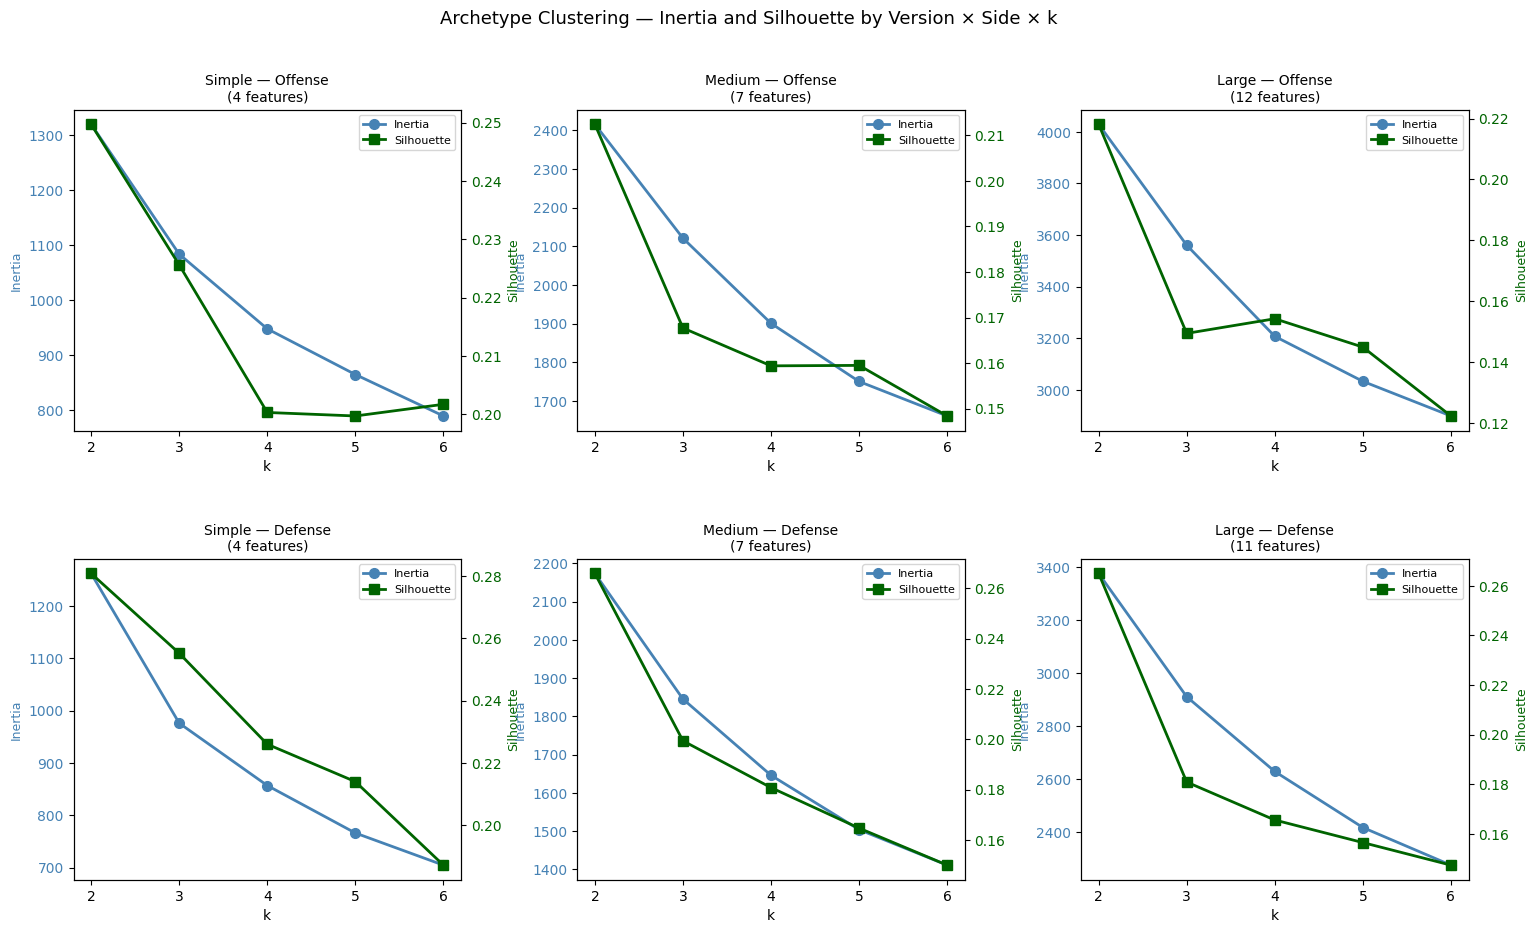

In [8]:
# ── Archetype Clustering — Three Feature Set Versions, k=2 through k=6 ────────
#
# Runs KMeans for every combination of:
#   version: simple (4 features), medium (7 features), large (11 features)
#   side:    offense, defense
#   k:       2, 3, 4, 5, 6
#
# Records inertia and silhouette score for every combination.
# Seed stability run on winning combination only (20 seeds).
# StandardScaler applied within each version — scaler fit on training pool only.
# RANDOM_SEED = 42 everywhere a random operation occurs.

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

RANDOM_SEED = 42
K_RANGE = range(2, 7)

# ── Pull training pool from int_team_season_features ─────────────
cur.execute("""
    SELECT
        team_name,
        season,
        rush_attempts,
        pass_attempts,
        off_plays,
        stat_games,
        off_explosiveness,
        off_line_yards,
        off_second_level_yards,
        off_open_field_yards,
        off_power_success,
        off_stuff_rate,
        off_std_downs_epa,
        off_pass_downs_epa,
        off_std_downs_success_rate,
        off_pass_downs_success_rate,
        def_havoc_total,
        def_havoc_front_seven,
        def_havoc_db,
        def_stuff_rate,
        def_explosiveness,
        def_line_yards,
        def_second_level_yards,
        def_rushing_epa,
        def_passing_epa,
        def_std_downs_epa,
        def_pass_downs_epa,
        def_pass_downs_success_rate,
        def_std_downs_success_rate
    FROM int.int_team_season_features
    WHERE season IN (2022, 2023, 2024, 2025)
      AND conference != 'FBS Independents'
      AND conference != 'Pac-12'
      AND NOT (conference = 'American Athletic' AND season = 2022)
      AND NOT (conference = 'Mountain West'     AND season = 2022)
      AND NOT (conference = 'Big 12'            AND season = 2022)
    ORDER BY team_name, season
""")
rows = cur.fetchall()
cols = [d[0] for d in cur.description]
tsf = pd.DataFrame(rows, columns=cols)

float_cols = [c for c in cols if c not in ('team_name', 'season')]
tsf[float_cols] = tsf[float_cols].astype(float)

# ── Derive rush_rate and plays_per_game ───────────────────────────
tsf['rush_rate']      = tsf['rush_attempts'] / (tsf['rush_attempts'] + tsf['pass_attempts'])
tsf['plays_per_game'] = tsf['off_plays'] / tsf['stat_games']

assert len(tsf) == 457, f"Expected 457 team-seasons, got {len(tsf)}"
assert tsf['rush_rate'].isna().sum() == 0, "Nulls in rush_rate"
assert tsf['plays_per_game'].isna().sum() == 0, "Nulls in plays_per_game"
print(f"Training pool loaded: {len(tsf)} team-seasons")
print(f"rush_rate range:      {tsf['rush_rate'].min():.3f} – {tsf['rush_rate'].max():.3f}")
print(f"plays_per_game range: {tsf['plays_per_game'].min():.1f} – {tsf['plays_per_game'].max():.1f}")

# ── Feature set definitions ───────────────────────────────────────
VERSIONS = {
    'simple': {
        'offense': ['rush_rate', 'off_explosiveness',
                    'off_std_downs_epa', 'off_pass_downs_epa'],
        'defense': ['def_havoc_total', 'def_stuff_rate',
                    'def_explosiveness', 'def_pass_downs_epa'],
    },
    'medium': {
        'offense': ['rush_rate', 'off_explosiveness', 'off_line_yards',
                    'off_open_field_yards', 'off_std_downs_epa',
                    'off_pass_downs_epa', 'plays_per_game'],
        'defense': ['def_havoc_front_seven', 'def_havoc_db', 'def_stuff_rate',
                    'def_explosiveness', 'def_line_yards',
                    'def_pass_downs_epa', 'def_std_downs_epa'],
    },
    'large': {
        'offense': ['rush_rate', 'off_explosiveness', 'off_line_yards',
                    'off_second_level_yards', 'off_open_field_yards',
                    'off_power_success', 'off_stuff_rate',
                    'off_std_downs_epa', 'off_pass_downs_epa',
                    'off_std_downs_success_rate', 'off_pass_downs_success_rate',
                    'plays_per_game'],
        'defense': ['def_havoc_front_seven', 'def_havoc_db', 'def_stuff_rate',
                    'def_explosiveness', 'def_line_yards', 'def_second_level_yards',
                    'def_rushing_epa', 'def_passing_epa',
                    'def_std_downs_epa', 'def_pass_downs_epa',
                    'def_pass_downs_success_rate'],
    },
}

# ── Run clustering — all versions × sides × k ────────────────────
results = []

for version, sides in VERSIONS.items():
    for side, features in sides.items():
        X = tsf[features].values
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)

        for k in K_RANGE:
            km = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=50)
            labels = km.fit_predict(X_scaled)
            sil = silhouette_score(X_scaled, labels)
            results.append({
                'version':    version,
                'side':       side,
                'k':          k,
                'n_features': len(features),
                'inertia':    round(km.inertia_, 3),
                'silhouette': round(sil, 4),
            })

results_df = pd.DataFrame(results)

# ── Print results table ───────────────────────────────────────────
print(f"\n=== Clustering results — inertia and silhouette by version × side × k ===")
print(f"\n{'Version':<10} {'Side':<10} {'k':>3} {'Features':>10} {'Inertia':>10} {'Silhouette':>12}")
print("-" * 60)
for version in ['simple', 'medium', 'large']:
    for side in ['offense', 'defense']:
        sub = results_df[(results_df['version'] == version) & (results_df['side'] == side)]
        for _, row in sub.iterrows():
            print(f"  {version:<8} {side:<10} {int(row['k']):>3} {int(row['n_features']):>10} "
                  f"{row['inertia']:>10.3f} {row['silhouette']:>12.4f}")
        print()

# ── Best silhouette per version × side ───────────────────────────
print(f"=== Best silhouette per version × side ===")
print(f"\n{'Version':<10} {'Side':<10} {'Best k':>8} {'Silhouette':>12}")
print("-" * 44)
for version in ['simple', 'medium', 'large']:
    for side in ['offense', 'defense']:
        sub = results_df[(results_df['version'] == version) & (results_df['side'] == side)]
        best = sub.loc[sub['silhouette'].idxmax()]
        print(f"  {version:<8} {side:<10} {int(best['k']):>8} {best['silhouette']:>12.4f}")

# ── Plot — 2 rows (offense, defense) × 3 cols (simple, medium, large) ────────
fig = plt.figure(figsize=(18, 10))
gs = gridspec.GridSpec(2, 3, hspace=0.4, wspace=0.3)

for col_idx, version in enumerate(['simple', 'medium', 'large']):
    for row_idx, side in enumerate(['offense', 'defense']):
        ax = fig.add_subplot(gs[row_idx, col_idx])
        sub = results_df[(results_df['version'] == version) & (results_df['side'] == side)]

        ax2 = ax.twinx()
        ax.plot(sub['k'], sub['inertia'], color='steelblue', marker='o',
                linewidth=2, markersize=7, label='Inertia')
        ax2.plot(sub['k'], sub['silhouette'], color='darkgreen', marker='s',
                 linewidth=2, markersize=7, label='Silhouette')

        ax.set_title(f'{version.capitalize()} — {side.capitalize()}\n({sub["n_features"].iloc[0]} features)',
                     fontsize=10)
        ax.set_xlabel('k')
        ax.set_ylabel('Inertia', color='steelblue', fontsize=9)
        ax2.set_ylabel('Silhouette', color='darkgreen', fontsize=9)
        ax.set_xticks(list(K_RANGE))
        ax.tick_params(axis='y', labelcolor='steelblue')
        ax2.tick_params(axis='y', labelcolor='darkgreen')

        lines1, labels1 = ax.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper right')

plt.suptitle('Archetype Clustering — Inertia and Silhouette by Version × Side × k',
             fontsize=13)
plt.show()

In [9]:
# ── Centroid inspection — large version, k=3 and k=4, both sides ─────────────

large_off_features = [
    'rush_rate', 'off_explosiveness', 'off_line_yards', 'off_second_level_yards',
    'off_open_field_yards', 'off_power_success', 'off_stuff_rate',
    'off_std_downs_epa', 'off_pass_downs_epa',
    'off_std_downs_success_rate', 'off_pass_downs_success_rate', 'plays_per_game'
]

large_def_features = [
    'def_havoc_front_seven', 'def_havoc_db', 'def_stuff_rate', 'def_explosiveness',
    'def_line_yards', 'def_second_level_yards', 'def_rushing_epa', 'def_passing_epa',
    'def_std_downs_epa', 'def_pass_downs_epa', 'def_pass_downs_success_rate'
]

for side, features in [('OFFENSE', large_off_features), ('DEFENSE', large_def_features)]:
    print(f"\n{'='*80}")
    print(f"LARGE — {side}")
    print(f"{'='*80}")

    X = tsf[features].values
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    for k in [3, 4]:
        km = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=50)
        labels = km.fit_predict(X_scaled)
        sil = silhouette_score(X_scaled, labels)

        centroids_orig = pd.DataFrame(
            scaler.inverse_transform(km.cluster_centers_),
            columns=features
        )

        print(f"\n{'─'*80}")
        print(f"k={k}  (silhouette={sil:.4f})")
        print(f"{'─'*80}")

        # ── Centroids ─────────────────────────────────────────────
        print(f"\n  Centroids (original units):")
        print(f"  {'Feature':<35}", end="")
        for c in range(k):
            print(f"  {'Cluster '+str(c):>14}", end="")
        print()
        print("  " + "-" * (35 + 16 * k))
        for feat in features:
            print(f"  {feat:<35}", end="")
            for c in range(k):
                print(f"  {centroids_orig.loc[c, feat]:>14.4f}", end="")
            print()

        # ── Cluster sizes ─────────────────────────────────────────
        print(f"\n  Cluster sizes:")
        for c in range(k):
            n = (labels == c).sum()
            print(f"    Cluster {c}: {n} team-seasons ({n/len(labels)*100:.1f}%)")

        # ── 8 closest team-seasons to each centroid ───────────────
        print(f"\n  Representative team-seasons (8 closest to centroid):")
        tsf[f'large_{side.lower()}_k{k}'] = labels
        for c in range(k):
            members = tsf[tsf[f'large_{side.lower()}_k{k}'] == c][
                ['team_name', 'season'] + features
            ].copy()
            centroid_vals = centroids_orig.loc[c, features].values
            members['dist'] = members[features].apply(
                lambda row: np.sqrt(((row.values - centroid_vals)**2).sum()), axis=1
            )
            closest = members.nsmallest(8, 'dist')
            print(f"\n    Cluster {c} (n={len(members)}):")
            for _, row in closest.iterrows():
                print(f"      {row['team_name']:<28} {int(row['season'])}")


LARGE — OFFENSE

────────────────────────────────────────────────────────────────────────────────
k=3  (silhouette=0.1495)
────────────────────────────────────────────────────────────────────────────────

  Centroids (original units):
  Feature                                   Cluster 0       Cluster 1       Cluster 2
  -----------------------------------------------------------------------------------
  rush_rate                                    0.5188          0.5342          0.5678
  off_explosiveness                            1.2621          1.2363          1.2813
  off_line_yards                               2.7415          3.0563          3.2920
  off_second_level_yards                       0.9902          1.0652          1.2547
  off_open_field_yards                         1.0990          1.1949          1.6060
  off_power_success                            0.6696          0.7445          0.7536
  off_stuff_rate                               0.2068          0.1689       

In [10]:
# ── Seed stability — large version, offense k=4, defense k=3 ─────────────────
#
# Run KMeans with 20 different random seeds for each winning combination.
# Build co-clustering matrix: fraction of seeds where each pair of team-seasons
# lands in the same cluster.
# A stable solution has near-1.0 co-clustering for same-cluster pairs and
# near-0.0 for cross-cluster pairs.
# Unstable pairs (co-clustering between 0.20 and 0.80) are flagged.

from itertools import combinations

SEEDS = list(range(20))

for side, features, k, label in [
    ('OFFENSE', large_off_features, 4, 'large_offense_k4'),
    ('DEFENSE', large_def_features, 3, 'large_defense_k3'),
]:
    print(f"\n{'='*70}")
    print(f"SEED STABILITY — {side}, k={k}, 20 seeds")
    print(f"{'='*70}")

    X = tsf[features].values
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # ── Collect labels across all seeds ──────────────────────────
    all_labels = []
    for seed in SEEDS:
        km = KMeans(n_clusters=k, random_state=seed, n_init=50)
        all_labels.append(km.fit_predict(X_scaled))

    # ── Co-clustering matrix ──────────────────────────────────────
    n = len(tsf)
    co_matrix = np.zeros((n, n))
    for labels in all_labels:
        for i in range(n):
            for j in range(n):
                if labels[i] == labels[j]:
                    co_matrix[i, j] += 1
    co_matrix /= len(SEEDS)

    # ── Summarize by canonical cluster assignment (seed=42) ───────
    km_canonical = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=50)
    canonical_labels = km_canonical.fit_predict(X_scaled)
    tsf[f'canonical_{side.lower()}'] = canonical_labels

    print(f"\nCo-clustering rate summary by canonical cluster pair:")
    print(f"(diagonal = same-cluster stability, off-diagonal = cross-cluster bleed)")
    print(f"\n{'':>12}", end="")
    for c in range(k):
        print(f"  Cluster {c:>2}", end="")
    print()
    print("  " + "-" * (12 + 12 * k))

    for c1 in range(k):
        print(f"  Cluster {c1:>2}  ", end="")
        idx1 = np.where(canonical_labels == c1)[0]
        for c2 in range(k):
            idx2 = np.where(canonical_labels == c2)[0]
            # Mean co-clustering rate between all pairs across c1 and c2
            rates = []
            for i in idx1:
                for j in idx2:
                    if i != j:
                        rates.append(co_matrix[i, j])
            mean_rate = np.mean(rates) if rates else 1.0
            print(f"  {mean_rate:>9.3f}", end="")
        print()

    # ── Unstable individual team-seasons ─────────────────────────
    print(f"\nUnstable team-seasons (co-clustering rate with own cluster < 0.80):")
    unstable = []
    for i in range(n):
        own_cluster = canonical_labels[i]
        own_idx = np.where(canonical_labels == own_cluster)[0]
        own_rates = [co_matrix[i, j] for j in own_idx if j != i]
        own_mean = np.mean(own_rates) if own_rates else 1.0
        if own_mean < 0.80:
            unstable.append({
                'team_name':   tsf.iloc[i]['team_name'],
                'season':      int(tsf.iloc[i]['season']),
                'cluster':     own_cluster,
                'stability':   round(own_mean, 3),
            })

    if unstable:
        unstable_df = pd.DataFrame(unstable).sort_values('stability')
        print(unstable_df.to_string(index=False))
    else:
        print("  None — all team-seasons stable across 20 seeds.")

    # ── Overall stability summary ─────────────────────────────────
    within_rates = []
    cross_rates = []
    for i in range(n):
        for j in range(i+1, n):
            if canonical_labels[i] == canonical_labels[j]:
                within_rates.append(co_matrix[i, j])
            else:
                cross_rates.append(co_matrix[i, j])

    print(f"\nOverall:")
    print(f"  Mean within-cluster co-clustering rate:  {np.mean(within_rates):.3f}")
    print(f"  Mean cross-cluster co-clustering rate:   {np.mean(cross_rates):.3f}")
    print(f"  Separation (within - cross):             {np.mean(within_rates) - np.mean(cross_rates):.3f}")


SEED STABILITY — OFFENSE, k=4, 20 seeds

Co-clustering rate summary by canonical cluster pair:
(diagonal = same-cluster stability, off-diagonal = cross-cluster bleed)

              Cluster  0  Cluster  1  Cluster  2  Cluster  3
  ------------------------------------------------------------
  Cluster  0        0.984      0.005      0.000      0.006
  Cluster  1        0.005      0.992      0.000      0.000
  Cluster  2        0.000      0.000      1.000      0.000
  Cluster  3        0.006      0.000      0.000      1.000

Unstable team-seasons (co-clustering rate with own cluster < 0.80):
       team_name  season  cluster  stability
Central Michigan    2025        0      0.199
             SMU    2023        1      0.600
   Bowling Green    2023        0      0.794

Overall:
  Mean within-cluster co-clustering rate:  0.994
  Mean cross-cluster co-clustering rate:   0.002
  Separation (within - cross):             0.992

SEED STABILITY — DEFENSE, k=3, 20 seeds

Co-clustering rate summ

## Archetype Clustering — Decisions Locked
*Recorded EDA 2, May 17 2026*

**Winning combination:** Large feature set for both sides.
**Offense:** k=4 | **Defense:** k=3

---

### Evidence summary

**Elbow:** Large offense shows a clear bend at k=4 — steep inertia decline
k=2 through k=4, then flattening. Large defense elbow at k=3. Both supported
by the inertia curves. Silhouette scores are modest across all versions
(0.15–0.28), consistent with teams existing on a continuous stylistic spectrum
rather than forming tight discrete groups.

**Centroid interpretation:** k=3 offense was rejected — clusters separated on
quality (EPA levels) rather than style (rush rate, tempo, run game structure).
k=4 offense produces four interpretable stylistic identities. k=3 defense
produces three interpretable identities. k=4 defense was rejected — the fourth
cluster fragmented an existing group without adding a recognizable new identity.

**Seed stability (20 seeds):**

Offense k=4:
- Within-cluster co-clustering rate: 0.994
- Cross-cluster co-clustering rate:  0.002
- Separation: 0.992
- Unstable team-seasons: 3 of 457 (Central Michigan 2025, SMU 2023,
  Bowling Green 2023) — all genuinely borderline, none invalidate the solution

Defense k=3:
- Within-cluster co-clustering rate: 0.999
- Cross-cluster co-clustering rate:  0.001
- Separation: 0.998
- Unstable team-seasons: 1 of 457 (Hawai'i 2024) — essentially perfect

---

### Cluster labels and identities

**Offense (k=4):**

| Index | Label | Characteristics |
|---|---|---|
| 0 | power_run | Run-heavy, strong line yards, efficient on standard downs, limited open field |
| 1 | spread_explosive | Highest open field yards, highest pass downs EPA, explosive, space-creation |
| 2 | tempo_pass | Pass-leaning, high tempo, moderate efficiency, good open field yards |
| 3 | grind_limited | Slowest tempo, lowest EPA both down types, highest stuff rate, deliberate |

**Defense (k=3):**

| Index | Label | Characteristics |
|---|---|---|
| 0 | soft_passive | Highest line yards allowed, highest EPA allowed rushing and passing |
| 1 | havoc_disruptive | Highest havoc front seven and DB, highest stuff rate, lowest line yards allowed |
| 2 | sound_fundamental | Moderate havoc, moderate EPA allowed, disciplined, doesn't give up big plays |

---

### Feature spaces (locked)

**Offense (12 features):** `rush_rate` (derived), `off_explosiveness`,
`off_line_yards`, `off_second_level_yards`, `off_open_field_yards`,
`off_power_success`, `off_stuff_rate`, `off_std_downs_epa`, `off_pass_downs_epa`,
`off_std_downs_success_rate`, `off_pass_downs_success_rate`, `plays_per_game`

**Defense (11 features):** `def_havoc_front_seven`, `def_havoc_db`,
`def_stuff_rate`, `def_explosiveness`, `def_line_yards`, `def_second_level_yards`,
`def_rushing_epa`, `def_passing_epa`, `def_std_downs_epa`, `def_pass_downs_epa`,
`def_pass_downs_success_rate`

**Derived inputs:**
- `rush_rate` = `rush_attempts / (rush_attempts + pass_attempts)`
- `plays_per_game` = `off_plays / stat_games`

Both derived from `int_team_season_features` directly. Zero null and zero
zero-denominator confirmed in training pool.

---

### What is locked after this cell

- Feature spaces are fixed — not revisited in subsequent sessions
- k=4 offense, k=3 defense — not revisited
- Cluster labels are fixed — index 0–3 offense, 0–2 defense map to the
  named identities above permanently
- Scaler: StandardScaler fit on the 457 team-season training pool
- The three unstable team-seasons retain their canonical (seed=42) assignment —
  borderline cases are accepted, not manually reassigned
- Authoritative source for archetype assignments: `int.int_team_season_features`
  columns `off_archetype_idx` and `def_archetype_idx` (to be written next)

**All engineering decisions in this cell are locked. They do not get
revisited in subsequent sessions without explicit direction and new
empirical evidence.**

In [11]:
# ── Write archetype assignments to int_team_season_features ──────────────────
#
# Offense: k=4, large feature set, StandardScaler fit on 457 team-season
#          training pool, RANDOM_SEED=42
# Defense: k=3, large feature set, StandardScaler fit on 457 team-season
#          training pool, RANDOM_SEED=42
#
# Cluster label mapping (locked):
#   Offense: 0=power_run, 1=spread_explosive, 2=tempo_pass, 3=grind_limited
#   Defense: 0=soft_passive, 1=havoc_disruptive, 2=sound_fundamental
#
# Columns written:
#   off_archetype_idx   smallint — integer cluster index 0-3
#   off_archetype       text     — named label
#   def_archetype_idx   smallint — integer cluster index 0-2
#   def_archetype       text     — named label
#
# ALL 534 rows in int_team_season_features are labeled, not just the
# 457-row training pool. Seasons and conferences outside the training
# pool (e.g. 2025 teams, Pac-12) get assigned to the nearest centroid
# using the scaler and centroids fit on the training pool.
# This is correct — we are applying a learned model to all available
# data, not restricting assignments to the training pool only.

RANDOM_SEED = 42

OFF_LABEL_MAP = {
    0: 'power_run',
    1: 'spread_explosive',
    2: 'tempo_pass',
    3: 'grind_limited',
}
DEF_LABEL_MAP = {
    0: 'soft_passive',
    1: 'havoc_disruptive',
    2: 'sound_fundamental',
}

# ── Pull ALL team-seasons for assignment ──────────────────────────
cur.execute("""
    SELECT
        team_name,
        season,
        rush_attempts,
        pass_attempts,
        off_plays,
        stat_games,
        off_explosiveness,
        off_line_yards,
        off_second_level_yards,
        off_open_field_yards,
        off_power_success,
        off_stuff_rate,
        off_std_downs_epa,
        off_pass_downs_epa,
        off_std_downs_success_rate,
        off_pass_downs_success_rate,
        def_havoc_front_seven,
        def_havoc_db,
        def_stuff_rate,
        def_explosiveness,
        def_line_yards,
        def_second_level_yards,
        def_rushing_epa,
        def_passing_epa,
        def_std_downs_epa,
        def_pass_downs_epa,
        def_pass_downs_success_rate
    FROM int.int_team_season_features
    ORDER BY team_name, season
""")
rows = cur.fetchall()
cols = [d[0] for d in cur.description]
all_tsf = pd.DataFrame(rows, columns=cols)
float_cols = [c for c in cols if c not in ('team_name', 'season')]
all_tsf[float_cols] = all_tsf[float_cols].astype(float)
all_tsf['rush_rate']      = all_tsf['rush_attempts'] / (all_tsf['rush_attempts'] + all_tsf['pass_attempts'])
all_tsf['plays_per_game'] = all_tsf['off_plays'] / all_tsf['stat_games']

print(f"All team-seasons loaded: {len(all_tsf)}")
print(f"Training pool (457): fit scaler and centroids on these")
print(f"Full pool ({len(all_tsf)}): assign all rows using trained scaler")

# ── Training pool mask ────────────────────────────────────────────
train_mask = (
    all_tsf['season'].isin([2022, 2023, 2024, 2025]) &
    ~all_tsf['season'].isin([])  # season filter already applied above
)
# Re-apply conference exclusions by joining — use tsf (already filtered)
train_ids = set(zip(tsf['team_name'], tsf['season']))
all_tsf['in_train'] = all_tsf.apply(
    lambda r: (r['team_name'], r['season']) in train_ids, axis=1
)
print(f"Training pool rows confirmed: {all_tsf['in_train'].sum()}")

# ── Fit scalers and models on training pool ───────────────────────
train = all_tsf[all_tsf['in_train']].copy()

# Offense
X_off_train = train[large_off_features].values
scaler_off = StandardScaler()
X_off_train_scaled = scaler_off.fit_transform(X_off_train)
km_off = KMeans(n_clusters=4, random_state=RANDOM_SEED, n_init=50)
km_off.fit(X_off_train_scaled)

# Defense
X_def_train = train[large_def_features].values
scaler_def = StandardScaler()
X_def_train_scaled = scaler_def.fit_transform(X_def_train)
km_def = KMeans(n_clusters=3, random_state=RANDOM_SEED, n_init=50)
km_def.fit(X_def_train_scaled)

# ── Assign all 534 rows ───────────────────────────────────────────
X_off_all = scaler_off.transform(all_tsf[large_off_features].values)
X_def_all = scaler_def.transform(all_tsf[large_def_features].values)

all_tsf['off_archetype_idx'] = km_off.predict(X_off_all).astype(int)
all_tsf['def_archetype_idx'] = km_def.predict(X_def_all).astype(int)
all_tsf['off_archetype']     = all_tsf['off_archetype_idx'].map(OFF_LABEL_MAP)
all_tsf['def_archetype']     = all_tsf['def_archetype_idx'].map(DEF_LABEL_MAP)

# ── Verify assignment distribution ───────────────────────────────
print(f"\nOffense archetype distribution (all {len(all_tsf)} team-seasons):")
print(all_tsf.groupby(['off_archetype_idx','off_archetype']).size().to_string())
print(f"\nDefense archetype distribution (all {len(all_tsf)} team-seasons):")
print(all_tsf.groupby(['def_archetype_idx','def_archetype']).size().to_string())

# ── Write to schema ───────────────────────────────────────────────
cur.execute("ALTER TABLE int.int_team_season_features ADD COLUMN IF NOT EXISTS off_archetype_idx smallint")
cur.execute("ALTER TABLE int.int_team_season_features ADD COLUMN IF NOT EXISTS off_archetype     text")
cur.execute("ALTER TABLE int.int_team_season_features ADD COLUMN IF NOT EXISTS def_archetype_idx smallint")
cur.execute("ALTER TABLE int.int_team_season_features ADD COLUMN IF NOT EXISTS def_archetype     text")

for _, row in all_tsf.iterrows():
    cur.execute("""
        UPDATE int.int_team_season_features
        SET off_archetype_idx = %s,
            off_archetype     = %s,
            def_archetype_idx = %s,
            def_archetype     = %s
        WHERE team_name = %s AND season = %s
    """, (
        int(row['off_archetype_idx']),
        row['off_archetype'],
        int(row['def_archetype_idx']),
        row['def_archetype'],
        row['team_name'],
        int(row['season']),
    ))

conn.commit()

# ── Verify write ──────────────────────────────────────────────────
cur.execute("""
    SELECT
        off_archetype_idx,
        off_archetype,
        def_archetype_idx,
        def_archetype,
        COUNT(*) AS n
    FROM int.int_team_season_features
    GROUP BY off_archetype_idx, off_archetype, def_archetype_idx, def_archetype
    ORDER BY off_archetype_idx, def_archetype_idx
""")
verify = pd.DataFrame(cur.fetchall(),
    columns=['off_idx','off_label','def_idx','def_label','n'])
print(f"\n=== Archetype assignments written to int_team_season_features ===")
print(verify.to_string(index=False))

cur.execute("""
    SELECT
        SUM(CASE WHEN off_archetype_idx IS NULL THEN 1 ELSE 0 END) AS off_nulls,
        SUM(CASE WHEN def_archetype_idx IS NULL THEN 1 ELSE 0 END) AS def_nulls,
        COUNT(*) AS total
    FROM int.int_team_season_features
""")
row = cur.fetchone()
print(f"\nTotal rows: {row[2]} | off_archetype nulls: {row[0]} | def_archetype nulls: {row[1]}")
assert row[0] == 0, f"Nulls in off_archetype_idx: {row[0]}"
assert row[1] == 0, f"Nulls in def_archetype_idx: {row[1]}"
print("All assertions passed. Archetype assignments locked.")

All team-seasons loaded: 534
Training pool (457): fit scaler and centroids on these
Full pool (534): assign all rows using trained scaler
Training pool rows confirmed: 457

Offense archetype distribution (all 534 team-seasons):
off_archetype_idx  off_archetype   
0                  power_run           148
1                  spread_explosive    131
2                  tempo_pass          137
3                  grind_limited       118

Defense archetype distribution (all 534 team-seasons):
def_archetype_idx  def_archetype    
0                  soft_passive         185
1                  havoc_disruptive     122
2                  sound_fundamental    227

=== Archetype assignments written to int_team_season_features ===
 off_idx        off_label  def_idx         def_label  n
       0        power_run        0      soft_passive 45
       0        power_run        1  havoc_disruptive 34
       0        power_run        2 sound_fundamental 69
       1 spread_explosive        0      soft_pas

In [12]:
# ── Write archetype assignments — single UPDATE with VALUES ───────
# Build one SQL statement instead of 534 individual updates.

from io import StringIO

# Build the assignments dataframe
records = all_tsf[['team_name','season','off_archetype_idx','off_archetype',
                    'def_archetype_idx','def_archetype']].copy()

# Use a single UPDATE with a VALUES join — much faster than row-by-row
values_sql = ", ".join([
    f"({row['off_archetype_idx']}, '{row['off_archetype']}', "
    f"{row['def_archetype_idx']}, '{row['def_archetype']}', "
    f"'{row['team_name'].replace(chr(39), chr(39)+chr(39))}', {row['season']})"
    for _, row in records.iterrows()
])

cur.execute(f"""
    UPDATE int.int_team_season_features AS t
    SET
        off_archetype_idx = v.off_archetype_idx,
        off_archetype     = v.off_archetype,
        def_archetype_idx = v.def_archetype_idx,
        def_archetype     = v.def_archetype
    FROM (VALUES {values_sql}) AS v(
        off_archetype_idx, off_archetype,
        def_archetype_idx, def_archetype,
        team_name, season
    )
    WHERE t.team_name = v.team_name
      AND t.season    = v.season::integer
""")
conn.commit()
print(f"Updated {cur.rowcount} rows")

# ── Verify ────────────────────────────────────────────────────────
cur.execute("""
    SELECT
        SUM(CASE WHEN off_archetype_idx IS NULL THEN 1 ELSE 0 END) AS off_nulls,
        SUM(CASE WHEN def_archetype_idx IS NULL THEN 1 ELSE 0 END) AS def_nulls,
        COUNT(*) AS total
    FROM int.int_team_season_features
""")
row = cur.fetchone()
print(f"Total rows: {row[2]} | off nulls: {row[0]} | def nulls: {row[1]}")
assert row[0] == 0, f"Nulls in off_archetype_idx: {row[0]}"
assert row[1] == 0, f"Nulls in def_archetype_idx: {row[1]}"
print("All assertions passed. Archetype assignments locked.")

Updated 534 rows
Total rows: 534 | off nulls: 0 | def nulls: 0
All assertions passed. Archetype assignments locked.


In [13]:
# ── Spot check — known teams vs expected assignments ──────────────
cur.execute("""
    SELECT team_name, season, off_archetype_idx, off_archetype,
           def_archetype_idx, def_archetype
    FROM int.int_team_season_features
    WHERE (team_name = 'Alabama'    AND season = 2025)
       OR (team_name = 'Ohio State' AND season = 2022)
       OR (team_name = 'LSU'        AND season = 2025)
       OR (team_name = 'Indiana'    AND season = 2025)
       OR (team_name = 'Tennessee'  AND season = 2024)
       OR (team_name = 'Utah'       AND season = 2024)
       OR (team_name = 'Texas A&M'  AND season = 2024)
       OR (team_name = 'Kentucky'   AND season = 2024)
       OR (team_name = 'Air Force'  AND season = 2024)
       OR (team_name = 'Georgia'    AND season = 2024)
    ORDER BY team_name, season
""")
rows = cur.fetchall()
spot = pd.DataFrame(rows, columns=['team','season','off_idx','off_label','def_idx','def_label'])
print("Spot check — known teams vs expected assignments:")
print(spot.to_string(index=False))

Spot check — known teams vs expected assignments:
      team  season  off_idx        off_label  def_idx         def_label
 Air Force    2024        0        power_run        0      soft_passive
   Alabama    2025        2       tempo_pass        1  havoc_disruptive
   Georgia    2024        2       tempo_pass        2 sound_fundamental
   Indiana    2025        1 spread_explosive        1  havoc_disruptive
  Kentucky    2024        0        power_run        2 sound_fundamental
       LSU    2025        3    grind_limited        1  havoc_disruptive
Ohio State    2022        1 spread_explosive        1  havoc_disruptive
 Tennessee    2024        0        power_run        1  havoc_disruptive
 Texas A&M    2024        0        power_run        1  havoc_disruptive
      Utah    2024        3    grind_limited        1  havoc_disruptive


## EDA 2 — Session 1 Stopping Point
*May 17 2026, resuming next session*

**Completed:**
- Schema inventory and int_game_model_features audit (condemned)
- wind_chill_f built into int_game_environment
- Offense archetypes (k=4, large feature set) built into int_team_season_features
- Defense archetypes (k=3, large feature set) built into int_team_season_features

**Remaining Part 1 (engineering pass):**
- Matchup features (4 columns)
- Style delta features (rush_rate_std_downs_delta, rush_rate_pass_downs_delta)
- Close game play count delta
- Sack rate delta features — decision needed (in or out of candidate list)

**Remaining Part 2:**
- Full column inventory across all int tables
- candidate_features.csv

**To resume:** Start new conversation, upload model_rebuild_plan and
this notebook. Read both before writing any code.

# III. Matchups

In [25]:
# ── Cell 1: Complete audit of all tables before any writes ────────────────────
#
# Rules this session:
#   - No assertion is ever written against a full table row count
#   - All null checks and row counts scoped to rebuild pool explicitly
#   - Rebuild pool filters applied identically everywhere:
#       seasons 2022-2025, conference_game=TRUE, weeks 5-14,
#       both teams in int_team_season_features,
#       no FBS Independents, no Pac-12,
#       no American Athletic 2022, no Mountain West 2022, no Big 12 2022
#   - No write cell without a preceding dry-run cell
#   - No write cell without explicit confirmation from you

import psycopg2
import pandas as pd
import numpy as np

RANDOM_SEED = 42
TRAIN_SEASONS = [2022, 2023, 2024, 2025]

conn = psycopg2.connect(
    host='127.0.0.1', port=5455, dbname='postgres',
    user='postgres', password='postgres'
)
cur = conn.cursor()

# ── 1. raw.games — full column list and row counts ────────────────
cur.execute("""
    SELECT column_name, data_type
    FROM information_schema.columns
    WHERE table_schema = 'raw' AND table_name = 'games'
    ORDER BY ordinal_position
""")
print("=== raw.games columns ===")
for row in cur.fetchall():
    print(f"  {row[0]:<45} {row[1]}")

cur.execute("SELECT COUNT(*) FROM raw.games")
print(f"\nraw.games total rows: {cur.fetchone()[0]}")

cur.execute("""
    SELECT season, COUNT(*) FROM raw.games
    GROUP BY season ORDER BY season
""")
print("raw.games by season:")
for row in cur.fetchall():
    print(f"  {row[0]}: {row[1]}")

# ── 2. int_game_team_features — total vs rebuild pool ────────────
cur.execute("SELECT COUNT(*) FROM int.int_game_team_features")
print(f"\nint_game_team_features total rows: {cur.fetchone()[0]}")

cur.execute("""
    SELECT COUNT(*)
    FROM int.int_game_team_features f
    JOIN raw.games g
        ON g.id = f.game_id
    JOIN int.int_team_season_features ts
        ON ts.team_name = f.team_name AND ts.season = f.season
    JOIN int.int_team_season_features opp
        ON opp.team_name = f.opponent AND opp.season = f.season
    WHERE g.season IN (2022, 2023, 2024, 2025)
      AND g.conference_game = TRUE
      AND g.week BETWEEN 5 AND 14
      AND ts.conference != 'FBS Independents'
      AND opp.conference != 'FBS Independents'
      AND ts.conference != 'Pac-12'
      AND opp.conference != 'Pac-12'
      AND NOT (ts.conference = 'American Athletic' AND g.season = 2022)
      AND NOT (ts.conference = 'Mountain West'     AND g.season = 2022)
      AND NOT (ts.conference = 'Big 12'            AND g.season = 2022)
""")
print(f"int_game_team_features rebuild-pool rows: {cur.fetchone()[0]}")

# ── 3. int_game_environment — total rows and join to rebuild pool ─
cur.execute("SELECT COUNT(*) FROM int.int_game_environment")
print(f"\nint_game_environment total rows: {cur.fetchone()[0]}")

cur.execute("""
    SELECT COUNT(*)
    FROM int.int_game_environment e
    JOIN raw.games g
        ON g.id = e.game_id
    JOIN int.int_team_season_features ht
        ON ht.team_name = g.home_team AND ht.season = g.season
    JOIN int.int_team_season_features at
        ON at.team_name = g.away_team AND at.season = g.season
    WHERE g.season IN (2022, 2023, 2024, 2025)
      AND g.conference_game = TRUE
      AND g.week BETWEEN 5 AND 14
      AND ht.conference != 'FBS Independents'
      AND at.conference != 'FBS Independents'
      AND ht.conference != 'Pac-12'
      AND at.conference != 'Pac-12'
      AND NOT (ht.conference = 'American Athletic' AND g.season = 2022)
      AND NOT (ht.conference = 'Mountain West'     AND g.season = 2022)
      AND NOT (ht.conference = 'Big 12'            AND g.season = 2022)
""")
print(f"int_game_environment rebuild-pool rows: {cur.fetchone()[0]}")

# ── 4. How many unique game_ids in the rebuild pool ───────────────
cur.execute("""
    SELECT COUNT(DISTINCT g.id)
    FROM raw.games g
    JOIN int.int_team_season_features ht
        ON ht.team_name = g.home_team AND ht.season = g.season
    JOIN int.int_team_season_features at
        ON at.team_name = g.away_team AND at.season = g.season
    WHERE g.season IN (2022, 2023, 2024, 2025)
      AND g.conference_game = TRUE
      AND g.week BETWEEN 5 AND 14
      AND ht.conference != 'FBS Independents'
      AND at.conference != 'FBS Independents'
      AND ht.conference != 'Pac-12'
      AND at.conference != 'Pac-12'
      AND NOT (ht.conference = 'American Athletic' AND g.season = 2022)
      AND NOT (ht.conference = 'Mountain West'     AND g.season = 2022)
      AND NOT (ht.conference = 'Big 12'            AND g.season = 2022)
""")
print(f"\nDistinct game_ids in rebuild pool: {cur.fetchone()[0]}")

# ── 5. Does int_game_matchup_features already exist ───────────────
cur.execute("""
    SELECT table_name
    FROM information_schema.tables
    WHERE table_schema = 'int'
      AND table_name = 'int_game_matchup_features'
""")
print(f"\nint_game_matchup_features exists: {bool(cur.fetchone())}")

# ── 6. off_matchup and def_matchup already in int_game_team_features
cur.execute("""
    SELECT column_name, data_type
    FROM information_schema.columns
    WHERE table_schema = 'int'
      AND table_name = 'int_game_team_features'
      AND column_name IN ('off_matchup', 'def_matchup')
""")
existing = cur.fetchall()
print(f"\nMatchup columns already in int_game_team_features: {[r[0] for r in existing]}")

# If they exist, show null counts scoped to rebuild pool
if existing:
    cur.execute("""
        SELECT
            SUM(CASE WHEN f.off_matchup IS NULL THEN 1 ELSE 0 END) AS off_nulls,
            SUM(CASE WHEN f.def_matchup IS NULL THEN 1 ELSE 0 END) AS def_nulls,
            COUNT(*) AS n
        FROM int.int_game_team_features f
        JOIN raw.games g
            ON g.id = f.game_id
        JOIN int.int_team_season_features ts
            ON ts.team_name = f.team_name AND ts.season = f.season
        JOIN int.int_team_season_features opp
            ON opp.team_name = f.opponent AND opp.season = f.season
        WHERE g.season IN (2022, 2023, 2024, 2025)
          AND g.conference_game = TRUE
          AND g.week BETWEEN 5 AND 14
          AND ts.conference != 'FBS Independents'
          AND opp.conference != 'FBS Independents'
          AND ts.conference != 'Pac-12'
          AND opp.conference != 'Pac-12'
          AND NOT (ts.conference = 'American Athletic' AND g.season = 2022)
          AND NOT (ts.conference = 'Mountain West'     AND g.season = 2022)
          AND NOT (ts.conference = 'Big 12'            AND g.season = 2022)
    """)
    row = cur.fetchone()
    print(f"  rebuild-pool rows: {row[2]} | off_matchup nulls: {row[0]} | def_matchup nulls: {row[1]}")

=== raw.games columns ===
  id                                            bigint
  season                                        integer
  week                                          integer
  season_type                                   text
  start_date                                    text
  start_time_et                                 text
  neutral_site                                  boolean
  conference_game                               boolean
  attendance                                    integer
  venue_id                                      bigint
  venue                                         text
  home_team                                     text
  home_conference                               text
  home_points                                   integer
  away_team                                     text
  away_conference                               text
  away_points                                   integer
  _ingested_at                                  

In [27]:
# ── Cell 2: Dry run — int_game_matchup_features ───────────────────────────────
#
# Builds home_off_vs_away_def and away_off_vs_home_def in memory.
# No writes. Confirms row count, nulls, and distribution before table creation.
#
# Source: raw.games joined to int_team_season_features for home and away team
#         archetypes. Full rebuild pool filter applied to both teams.
#
# Expected: 1,729 rows, zero nulls, 12 distinct combinations in each column.

cur.execute("""
    SELECT
        g.id                                            AS game_id,
        g.season,
        g.week,
        g.home_team,
        g.away_team,
        ht.off_archetype || '_vs_' || at.def_archetype AS home_off_vs_away_def,
        at.off_archetype || '_vs_' || ht.def_archetype AS away_off_vs_home_def
    FROM raw.games g
    JOIN int.int_team_season_features ht
        ON ht.team_name = g.home_team AND ht.season = g.season
    JOIN int.int_team_season_features at
        ON at.team_name = g.away_team AND at.season = g.season
    WHERE g.season IN (2022, 2023, 2024, 2025)
      AND g.conference_game = TRUE
      AND g.week BETWEEN 5 AND 14
      AND ht.conference != 'FBS Independents'
      AND at.conference != 'FBS Independents'
      AND ht.conference != 'Pac-12'
      AND at.conference != 'Pac-12'
      AND NOT (ht.conference = 'American Athletic' AND g.season = 2022)
      AND NOT (at.conference = 'American Athletic' AND g.season = 2022)
      AND NOT (ht.conference = 'Mountain West'     AND g.season = 2022)
      AND NOT (at.conference = 'Mountain West'     AND g.season = 2022)
      AND NOT (ht.conference = 'Big 12'            AND g.season = 2022)
      AND NOT (at.conference = 'Big 12'            AND g.season = 2022)
    ORDER BY g.id
""")
rows = cur.fetchall()
cols = ['game_id','season','week','home_team','away_team',
        'home_off_vs_away_def','away_off_vs_home_def']
dry = pd.DataFrame(rows, columns=cols)

# ── Row count and null check ──────────────────────────────────────
print(f"Rows returned: {len(dry)}")
print(f"Nulls in home_off_vs_away_def: {dry['home_off_vs_away_def'].isna().sum()}")
print(f"Nulls in away_off_vs_home_def: {dry['away_off_vs_home_def'].isna().sum()}")
print(f"Distinct combinations in home_off_vs_away_def: {dry['home_off_vs_away_def'].nunique()}")
print(f"Distinct combinations in away_off_vs_home_def: {dry['away_off_vs_home_def'].nunique()}")

# ── Distribution ──────────────────────────────────────────────────
print("\n=== home_off_vs_away_def distribution ===")
print(dry['home_off_vs_away_def'].value_counts().to_string())

print("\n=== away_off_vs_home_def distribution ===")
print(dry['away_off_vs_home_def'].value_counts().to_string())

# ── Sample rows ───────────────────────────────────────────────────
print("\n=== Sample rows (5 games) ===")
print(dry[['game_id','season','week','home_team','away_team',
           'home_off_vs_away_def','away_off_vs_home_def']].head(5).to_string(index=False))

Rows returned: 1729
Nulls in home_off_vs_away_def: 0
Nulls in away_off_vs_home_def: 0
Distinct combinations in home_off_vs_away_def: 12
Distinct combinations in away_off_vs_home_def: 12

=== home_off_vs_away_def distribution ===
home_off_vs_away_def
power_run_vs_sound_fundamental           218
tempo_pass_vs_sound_fundamental          184
grind_limited_vs_sound_fundamental       183
spread_explosive_vs_soft_passive         156
tempo_pass_vs_soft_passive               151
power_run_vs_soft_passive                146
spread_explosive_vs_sound_fundamental    140
grind_limited_vs_soft_passive            123
tempo_pass_vs_havoc_disruptive           117
spread_explosive_vs_havoc_disruptive     106
power_run_vs_havoc_disruptive            105
grind_limited_vs_havoc_disruptive        100

=== away_off_vs_home_def distribution ===
away_off_vs_home_def
power_run_vs_sound_fundamental           209
grind_limited_vs_sound_fundamental       187
tempo_pass_vs_sound_fundamental          166
tempo_pass_

In [35]:
# ── Cell 3 verification — data already written, verify only ──────────────────

cur.execute("""
    SELECT
        COUNT(*)                                                                AS total_rows,
        COALESCE(SUM(CASE WHEN m.home_off_vs_away_def IS NULL THEN 1 END), 0) AS home_nulls,
        COALESCE(SUM(CASE WHEN m.away_off_vs_home_def IS NULL THEN 1 END), 0) AS away_nulls
    FROM int.int_game_matchup_features m
    JOIN raw.games g
        ON g.id = m.game_id
    JOIN int.int_team_season_features ht
        ON ht.team_name = g.home_team AND ht.season = g.season
    JOIN int.int_team_season_features at
        ON at.team_name = g.away_team AND at.season = g.season
    WHERE g.season IN (2022, 2023, 2024, 2025)
      AND g.conference_game = TRUE
      AND g.week BETWEEN 5 AND 14
      AND ht.conference != 'FBS Independents'
      AND at.conference != 'FBS Independents'
      AND ht.conference != 'Pac-12'
      AND at.conference != 'Pac-12'
      AND NOT (ht.conference = 'American Athletic' AND g.season = 2022)
      AND NOT (at.conference = 'American Athletic' AND g.season = 2022)
      AND NOT (ht.conference = 'Mountain West'     AND g.season = 2022)
      AND NOT (at.conference = 'Mountain West'     AND g.season = 2022)
      AND NOT (ht.conference = 'Big 12'            AND g.season = 2022)
      AND NOT (at.conference = 'Big 12'            AND g.season = 2022)
""")
row = cur.fetchone()
print(f"Rebuild-pool rows: {row[0]} | home_nulls: {row[1]} | away_nulls: {row[2]}")

assert row[0] == 1729, f"Expected 1729 rows, got {row[0]}"
assert row[1] == 0,    f"Nulls in home_off_vs_away_def: {row[1]}"
assert row[2] == 0,    f"Nulls in away_off_vs_home_def: {row[2]}"
print("All assertions passed.")

# ── Distribution check — must match Cell 2 exactly ────────────────
cur.execute("""
    SELECT home_off_vs_away_def, COUNT(*) AS n
    FROM int.int_game_matchup_features
    GROUP BY home_off_vs_away_def
    ORDER BY n DESC
""")
print("\n=== home_off_vs_away_def distribution after write ===")
for row in cur.fetchall():
    print(f"  {row[0]:<50} {row[1]}")

Rebuild-pool rows: 1729 | home_nulls: 0 | away_nulls: 0
All assertions passed.

=== home_off_vs_away_def distribution after write ===
  power_run_vs_sound_fundamental                     218
  tempo_pass_vs_sound_fundamental                    184
  grind_limited_vs_sound_fundamental                 183
  spread_explosive_vs_soft_passive                   156
  tempo_pass_vs_soft_passive                         151
  power_run_vs_soft_passive                          146
  spread_explosive_vs_sound_fundamental              140
  grind_limited_vs_soft_passive                      123
  tempo_pass_vs_havoc_disruptive                     117
  spread_explosive_vs_havoc_disruptive               106
  power_run_vs_havoc_disruptive                      105
  grind_limited_vs_havoc_disruptive                  100


In [36]:
# ── Cell 4: Audit source columns for style delta features ────────────────────
#
# Style delta features require season-level team statistics.
# Source table: int_team_season_features
# Need to confirm exact column names and null coverage before building deltas.
#
# Candidates:
#   rush_rate_std_downs      — rush rate on standard downs
#   rush_rate_pass_downs     — rush rate on passing downs
#   close_game_play_count    — plays in close game situations
#   sack_rate               — sacks allowed per pass attempt (offense)
#                           — or sacks generated per pass rush (defense)
#
# Null check scoped to rebuild pool only:
#   seasons 2022-2025, conference exclusions per EDA 1

# ── 1. What columns exist in int_team_season_features ────────────
cur.execute("""
    SELECT column_name, data_type
    FROM information_schema.columns
    WHERE table_schema = 'int'
      AND table_name = 'int_team_season_features'
    ORDER BY ordinal_position
""")
all_cols = cur.fetchall()
print("=== int_team_season_features — full column list ===")
for col, dtype in all_cols:
    print(f"  {col:<45} {dtype}")

# ── 2. Which candidate columns exist ─────────────────────────────
candidates = [
    'rush_rate_std_downs',
    'rush_rate_pass_downs',
    'close_game_play_count',
    'sack_rate',
    'sacks',
    'pass_attempts',
    'off_std_downs_rush_rate',
    'off_pass_downs_rush_rate',
    'std_downs_rush_rate',
    'pass_downs_rush_rate',
]
existing_col_names = {r[0] for r in all_cols}
print("\n=== Candidate column existence check ===")
for c in candidates:
    status = 'EXISTS' if c in existing_col_names else 'MISSING'
    print(f"  {c:<45} {status}")

# ── 3. Null counts for existing candidates in rebuild pool ────────
existing_candidates = [c for c in candidates if c in existing_col_names]
if existing_candidates:
    null_selects = ", ".join([
        f"COALESCE(SUM(CASE WHEN {c} IS NULL THEN 1 END), 0) AS {c}"
        for c in existing_candidates
    ])
    cur.execute(f"""
        SELECT
            COUNT(*) AS total_rows,
            {null_selects}
        FROM int.int_team_season_features
        WHERE season IN (2022, 2023, 2024, 2025)
          AND conference != 'FBS Independents'
          AND conference != 'Pac-12'
          AND NOT (conference = 'American Athletic' AND season = 2022)
          AND NOT (conference = 'Mountain West'     AND season = 2022)
          AND NOT (conference = 'Big 12'            AND season = 2022)
    """)
    row = cur.fetchone()
    col_names = ['total_rows'] + existing_candidates
    result = dict(zip(col_names, row))
    print(f"\n=== Null counts in rebuild pool (total rows: {result['total_rows']}) ===")
    for c in existing_candidates:
        print(f"  {c:<45} nulls: {result[c]}")

=== int_team_season_features — full column list ===
  team_name                                     text
  season                                        integer
  team_id                                       integer
  conference                                    text
  city                                          text
  state                                         text
  latitude                                      numeric
  longitude                                     numeric
  timezone                                      text
  games_played                                  bigint
  wins                                          bigint
  losses                                        bigint
  win_pct                                       numeric
  avg_points_scored                             numeric
  avg_points_allowed                            numeric
  avg_point_diff                                numeric
  home_games                                    bigint
  away_games   

In [40]:
# ── Cell 5: Audit int_game_team_features for style delta source columns ───────
#
# rush_rate_std_downs and rush_rate_pass_downs are missing from
# int_team_season_features. Check int_game_team_features for game-level
# versions of these columns before deciding whether to derive from raw.plays.
#
# Also confirm close_game_play_count exists and check null coverage
# scoped to rebuild pool.

# ── 1. Full column list of int_game_team_features ─────────────────
cur.execute("""
    SELECT column_name, data_type
    FROM information_schema.columns
    WHERE table_schema = 'int'
      AND table_name = 'int_game_team_features'
    ORDER BY ordinal_position
""")
all_gtf_cols = cur.fetchall()
print("=== int_game_team_features — full column list ===")
for col, dtype in all_gtf_cols:
    print(f"  {col:<45} {dtype}")

# ── 2. Null counts for relevant columns in rebuild pool ───────────
relevant = [
    c for c, _ in all_gtf_cols
    if any(x in c for x in [
        'rush', 'std_down', 'pass_down', 'close_game', 'sack', 'havoc'
    ])
]

print(f"\n=== Relevant columns found: {relevant} ===")

if relevant:
    null_selects = ", ".join([
        f"COALESCE(SUM(CASE WHEN f.{c} IS NULL THEN 1 END), 0) AS {c}"
        for c in relevant
    ])
    cur.execute(f"""
        SELECT
            COUNT(*) AS total_rows,
            {null_selects}
        FROM int.int_game_team_features f
        JOIN raw.games g
            ON g.id = f.game_id
        JOIN int.int_team_season_features ts
            ON ts.team_name = f.team_name AND ts.season = f.season
        JOIN int.int_team_season_features opp
            ON opp.team_name = f.opponent AND opp.season = f.season
        WHERE g.season IN (2022, 2023, 2024, 2025)
          AND g.conference_game = TRUE
          AND g.week BETWEEN 5 AND 14
          AND ts.conference != 'FBS Independents'
          AND opp.conference != 'FBS Independents'
          AND ts.conference != 'Pac-12'
          AND opp.conference != 'Pac-12'
          AND NOT (ts.conference = 'American Athletic' AND g.season = 2022)
          AND NOT (opp.conference = 'American Athletic' AND g.season = 2022)
          AND NOT (ts.conference = 'Mountain West'     AND g.season = 2022)
          AND NOT (opp.conference = 'Mountain West'     AND g.season = 2022)
          AND NOT (ts.conference = 'Big 12'            AND g.season = 2022)
          AND NOT (opp.conference = 'Big 12'            AND g.season = 2022)
    """)
    row = cur.fetchone()
    col_names = ['total_rows'] + relevant
    result = dict(zip(col_names, row))
    print(f"\n=== Null counts in rebuild pool (total rows: {result['total_rows']}) ===")
    for c in relevant:
        print(f"  {c:<45} nulls: {result[c]}")

# ── 3. Check raw.plays for down-type rush rate source data ────────
cur.execute("""
    SELECT column_name, data_type
    FROM information_schema.columns
    WHERE table_schema = 'raw'
      AND table_name = 'plays'
    ORDER BY ordinal_position
""")
plays_cols = cur.fetchall()
print("\n=== raw.plays — full column list ===")
for col, dtype in plays_cols:
    print(f"  {col:<45} {dtype}")

=== int_game_team_features — full column list ===
  game_id                                       bigint
  season                                        integer
  week                                          integer
  game_date                                     date
  team_name                                     text
  opponent                                      text
  points_scored                                 integer
  points_allowed                                integer
  win                                           integer
  off_epa_per_play                              numeric
  def_epa_per_play_allowed                      numeric
  close_game_epa_per_play                       numeric
  close_game_play_count                         bigint
  close_game_def_epa_per_play                   numeric
  close_game_def_play_count                     bigint
  game_script                                   text
  game_script_avg_margin                        numeric
  last3_off_e

## EDA 2 — Session 2 Stopping Point
*May 18 2026, resuming next session*

**Completed this session:**
- `off_matchup` and `def_matchup` added to `int_game_team_features` — string labels encoding this team's offensive archetype vs opponent's defensive archetype and vice versa. 3,458 rebuild-pool rows, zero nulls verified.
- `int_game_matchup_features` created — new table, one row per game, `game_id` primary key. Columns `home_off_vs_away_def` and `away_off_vs_home_def`. 1,729 rows, zero nulls, all 12 archetype combinations present, verified against dry run.

**Remaining Part 1 (engineering pass):**

The following features have not been built. They require a full design conversation before any code is written.

- `game_script` metrics — **requires dedicated conversation before next session begins.** `game_script` is derived from `raw.plays` using score differential at the time of each play. Every performance metric needs its own version broken out by game script context. These features affect spread and total points for different structural reasons: game script affects play calling and scoring pace (total points) and execution consistency and late-game margin (spread). The exact definitions, down-type breakouts, CTD construction, and table destination must be agreed before writing any code.

- `rush_rate_std_downs_delta` and `rush_rate_pass_downs_delta` — derived from `raw.plays`. Standard downs defined as 1st down, 2nd and ≤7, 3rd and ≤4, 4th and ≤4. Pass downs defined as 2nd and 8+, 3rd and 5+, 4th and 5+. Source columns confirmed absent from `int_team_season_features` and `int_game_team_features` — must be built from play-level data.

- Close game CTD features — `close_game_play_count`, `close_game_def_play_count`, `close_game_epa_per_play`, `close_game_def_epa_per_play` all exist in `int_game_team_features` at the game level. CTD versions (cumulative average through prior games in the season) need to be built and written to `int_game_team_features`.

- Season-level delta features from `int_team_season_features` — all source columns confirmed to exist with zero nulls: `off_std_downs_success_rate_delta`, `off_pass_downs_success_rate_delta`, `def_std_downs_success_rate_delta`, `def_pass_downs_success_rate_delta`, `sack_rate_delta` (`sacks / pass_attempts`).

**Remaining Part 2:**
- Full column inventory across all int tables
- `candidate_features.csv`

**Critical rule for next session:**
Every assertion scoped to rebuild pool — never against full table. `int_game_team_features` has 29,472 rows covering 742 teams including FCS and non-FBS. Rebuild pool is 3,458 team-rows (1,729 games × 2). All null checks and row counts must join through `raw.games` and both sides of `int_team_season_features` with full EDA 1 filters applied to both teams.

**Full rebuild pool filter — must appear in every query, applied to both teams:**
```sql
WHERE g.season IN (2022, 2023, 2024, 2025)
  AND g.conference_game = TRUE
  AND g.week BETWEEN 5 AND 14
  AND ts.conference  != 'FBS Independents'
  AND opp.conference != 'FBS Independents'
  AND ts.conference  != 'Pac-12'
  AND opp.conference != 'Pac-12'
  AND NOT (ts.conference  = 'American Athletic' AND g.season = 2022)
  AND NOT (opp.conference = 'American Athletic' AND g.season = 2022)
  AND NOT (ts.conference  = 'Mountain West'     AND g.season = 2022)
  AND NOT (opp.conference = 'Mountain West'     AND g.season = 2022)
  AND NOT (ts.conference  = 'Big 12'            AND g.season = 2022)
  AND NOT (opp.conference = 'Big 12'            AND g.season = 2022)
```

**To resume:** Start new conversation, upload model_rebuild_plan and this notebook. Have the full game script design conversation before writing any code related to game script metrics.